# RQ1 Part 2 — Full UMLS Pool Semantic Entropy

**Depends on Part 1 artifacts only.** This notebook does **not** regenerate
perturbations, run Marian back-translation, call `.generate()`, or load
generative LLMs.

Required input:
- `outputs/rq1/intermediate/rq1_model_outputs.csv` (encoder outputs + metadata from Part 1)

Also used:
- `outputs/rq1/tables/rq1_entropy_scores.csv` (Part 1 mesh-pool entropy for side-by-side comparison)
- Setup-loaded `cui_pool` from `~/data/umls/pools/cui_pool_full_umls.pkl`

Run the Setup cell first, then P2.1 → P2.6 in order.


In [1]:
# === Setup (Part 2) — keep byte-identical across RQ notebooks ===
import json
import os
import pickle
from pathlib import Path

import torch
from transformers import AutoModel, AutoModelForCausalLM, AutoTokenizer

CONFIG_PATH = (Path("..") / "config.json").resolve()
with open(CONFIG_PATH, "r", encoding="utf-8") as _f:
    CFG = json.load(_f)

PROJECT_ROOT = CONFIG_PATH.parent


def _expand_tree(obj):
    """Expand ~ in all string paths; leave non-strings / null unchanged."""
    if isinstance(obj, dict):
        return {k: _expand_tree(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_expand_tree(v) for v in obj]
    if isinstance(obj, str):
        return os.path.expanduser(obj)
    return obj


CFG = _expand_tree(CFG)


def _resolve_cfg_path(p):
    if p is None:
        return None
    path = Path(p)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path


def _model_src(key: str) -> str:
    """Return local path or HF hub id for a model key in CFG['models']."""
    if key not in CFG["models"]:
        raise KeyError(f"Unknown model key {key!r}. Choose from: {sorted(CFG['models'])}")
    return CFG["models"][key]


def load_generative(key: str):
    src = _model_src(key)
    tokenizer = AutoTokenizer.from_pretrained(src, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        src,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
    )
    return tokenizer, model


def load_encoder(key: str):
    src = _model_src(key)
    tokenizer = AutoTokenizer.from_pretrained(src)
    model = AutoModel.from_pretrained(src)
    return tokenizer, model


def free_model(model):
    del model
    torch.cuda.empty_cache()


_pool_path = _resolve_cfg_path(CFG["pool_full"])
with open(_pool_path, "rb") as _f:
    cui_pool = pickle.load(_f)

_n_cuis = cui_pool.get("n_cuis", len(cui_pool.get("cuis", {})))
print(f"Config: {CONFIG_PATH}")
print(f"Loaded CUI pool from: {_pool_path}")
print(f"Pool type: {cui_pool.get('pool_type', 'unknown')} | unique CUIs: {_n_cuis:,}")
if _n_cuis < 10_000:
    print("WARNING: CUI count looks like the MeSH subset (~1,201), not full UMLS.")
else:
    print("Confirmed: full_umls-scale CUI pool loaded.")


/home/s224858267/.conda/envs/torch_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config: /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/config.json
Loaded CUI pool from: /home/s224858267/data/umls/pools/cui_pool_full_umls.pkl
Pool type: full_umls | unique CUIs: 3,341,331
Confirmed: full_umls-scale CUI pool loaded.


# PART 2 — Full UMLS Pool Semantic Entropy (Sensitivity / Depth Analysis)

**Do not modify Part 1 cells above.** This section re-assigns CUIs using the full
UMLS 2026AA pool (~3.34M CUIs) via a SapBERT + FAISS embedding index, then
recomputes semantic entropy for comparison with the Part 1 MeSH-linker pool
(~1,201 CUIs).

| Setting | Role |
|---|---|
| Primary | Full vocabulary + `MIN_FORM_LEN` filter (default 3) |
| Sensitivity | `PREFERRED_ONLY=True` keeps TTY ∈ {PT, PN} only |

Model **inference is not re-run**. Inputs come from `outputs/rq1/intermediate/rq1_model_outputs.csv`.
CUI assignment uses SapBERT retrieval + the five-rule disambiguation protocol
(exact match → contextual cosine → ST21pv filter → confidence threshold → frequency tiebreak).


## P2.1) Pool preparation (length filter + preferred-only sensitivity flag)

Loads `cui_pool` from the Setup cell (full_umls). Builds the active `(CUI, surface_form)`
list for indexing, and prints sizes for **full / full+lenfilter / preferred-only**.


In [2]:
# === PART 2: Full-UMLS pool preparation =====================================
# Flags (primary config: PREFERRED_ONLY=False, MIN_FORM_LEN=3)
MIN_FORM_LEN = 3
PREFERRED_ONLY = False          # True = sensitivity analysis only (TTY in {PT, PN})
PREFERRED_TTYS = {"PT", "PN"}
CONFIDENCE_THRESHOLD = 0.70     # five-rule protocol
FAISS_TOP_K = 50
SAPBERT_ID = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
EMBED_BATCH_SIZE = 512

from collections import Counter, defaultdict
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

assert "cui_pool" in globals() and isinstance(cui_pool, dict), (
    "cui_pool missing — run the Setup cell first (full_umls pickle)."
)
assert cui_pool.get("pool_type") == "full_umls", (
    f"Expected pool_type=full_umls, got {cui_pool.get('pool_type')!r}"
)
_raw_cuis = cui_pool["cuis"]
print(
    f"Loaded cui_pool: type={cui_pool.get('pool_type')} | "
    f"CUIs={cui_pool.get('n_cuis'):,} | forms={cui_pool.get('n_surface_forms'):,}"
)

def _has_alpha(s: str) -> bool:
    return any(ch.isalpha() for ch in s)

# --- Single pass over pickle: full stats + length-filtered form->CUIs ---
_full_n_forms = 0
_full_cuis = set()
_len_form_to_cuis = defaultdict(set)
_cuis_with_kept_form = set()
_n_short = _n_noalpha = 0
_forms_seen_full = set()
_forms_seen_len = set()

for cui, rec in tqdm(_raw_cuis.items(), desc="Pool filter pass", unit=" CUI"):
    _full_cuis.add(cui)
    for form in rec.get("surface_forms", ()):
        s = str(form).strip()
        _full_n_forms += 1
        _forms_seen_full.add(s)
        if len(s) < MIN_FORM_LEN:
            _n_short += 1
            continue
        if not _has_alpha(s):
            _n_noalpha += 1
            continue
        _len_form_to_cuis[s].add(cui)
        _forms_seen_len.add(s)
        _cuis_with_kept_form.add(cui)

_unreachable = _full_cuis - _cuis_with_kept_form
print(f"[full]              forms={len(_forms_seen_full):,} | CUIs={len(_full_cuis):,} "
      f"(raw form refs={_full_n_forms:,})")
print(f"[full+lenfilter]    forms={len(_forms_seen_len):,} | CUIs={len(_cuis_with_kept_form):,}")
print(f"  dropped short(<{MIN_FORM_LEN}): {_n_short:,} | no-alpha: {_n_noalpha:,}")
print(f"  forms removed: {len(_forms_seen_full) - len(_forms_seen_len):,}")
print(f"  CUIs losing ALL surface forms (unreachable): {len(_unreachable):,}")
del _forms_seen_full
gc.collect()

# --- Preferred-only (TTY in {PT, PN}) via MRCONSO — form-level TTY ---
_umls_meta = Path(
    CFG.get("umls_meta", str(Path.home() / "data/umls/2026AA/2026AA/META"))
).expanduser()
_mrconso = _umls_meta / "MRCONSO.RRF"
_pref_form_to_cuis = defaultdict(set)
_pref_n_raw = 0
if _mrconso.is_file():
    print(f"Streaming preferred-only forms from {_mrconso} ...")
    with open(_mrconso, "r", encoding="utf-8", errors="replace") as _fh:
        for _line in tqdm(_fh, desc="MRCONSO preferred", unit=" lines"):
            p = _line.rstrip("\n").split("|")
            if len(p) <= 16:
                continue
            if p[1] != "ENG" or p[16] != "N":
                continue
            if p[12] not in PREFERRED_TTYS:
                continue
            s = p[14].strip()
            _pref_n_raw += 1
            if len(s) < MIN_FORM_LEN or not _has_alpha(s):
                continue
            _pref_form_to_cuis[s].add(p[0])
    print(
        f"[preferred-only]    forms={len(_pref_form_to_cuis):,} | "
        f"CUIs={len({c for cuis in _pref_form_to_cuis.values() for c in cuis}):,} "
        f"(raw PT/PN rows={_pref_n_raw:,}, after lenfilter)"
    )
else:
    print(
        f"[preferred-only]    MRCONSO not found at {_mrconso} — size unavailable "
        f"(will error if PREFERRED_ONLY=True)."
    )

# --- Active configuration ---
if PREFERRED_ONLY:
    if not _pref_form_to_cuis:
        raise RuntimeError("PREFERRED_ONLY=True but no preferred pairs available.")
    _form_to_cuis = _pref_form_to_cuis
    _pool_config_name = f"sapbert_pref_tty_len{MIN_FORM_LEN}"
else:
    _form_to_cuis = _len_form_to_cuis
    _pool_config_name = f"sapbert_full_len{MIN_FORM_LEN}"

_unique_forms = sorted(_form_to_cuis.keys())
_form_cui_pairs = [(c, f) for f, cuis in _form_to_cuis.items() for c in sorted(cuis)]

_cui_st21pv = {c: bool(rec.get("st21pv", False)) for c, rec in _raw_cuis.items()}
_cui_n_forms = {c: len(rec.get("surface_forms", ())) for c, rec in _raw_cuis.items()}

_exact_index = defaultdict(set)
for _f, _cuis in _form_to_cuis.items():
    _exact_index[_f.casefold()].update(_cuis)

print(f"\nACTIVE config: {_pool_config_name} | PREFERRED_ONLY={PREFERRED_ONLY}")
print(f"  unique surface forms to embed: {len(_unique_forms):,}")
print(f"  (CUI, form) pairs: {len(_form_cui_pairs):,}")
print("Size comparison:")
print(f"  full            forms={cui_pool.get('n_surface_forms'):,} CUIs={len(_full_cuis):,}")
print(f"  full+lenfilter  forms={len(_forms_seen_len):,} CUIs={len(_cuis_with_kept_form):,}")
print(
    f"  preferred-only  forms={len(_pref_form_to_cuis):,} | "
    f"CUIs={len({c for cuis in _pref_form_to_cuis.values() for c in cuis}):,}"
)


Loaded cui_pool: type=full_umls | CUIs=3,341,331 | forms=7,757,273


Pool filter pass:   0%|          | 0/3341331 [00:00<?, ? CUI/s]

Pool filter pass:   0%|          | 7391/3341331 [00:00<00:45, 73898.44 CUI/s]

Pool filter pass:   0%|          | 14781/3341331 [00:00<00:50, 65640.87 CUI/s]

Pool filter pass:   1%|          | 21405/3341331 [00:00<00:50, 65530.97 CUI/s]

...

MRCONSO preferred: 17986997 lines [00:18, 1005303.46 lines/s]

MRCONSO preferred: 18064970 lines [00:18, 959494.71 lines/s] 

[preferred-only]    forms=2,029,159 | CUIs=1,535,536 (raw PT/PN rows=2,456,151, after lenfilter)



ACTIVE config: sapbert_full_len3 | PREFERRED_ONLY=False
  unique surface forms to embed: 7,653,278
  (CUI, form) pairs: 7,752,661
Size comparison:
  full            forms=7,757,273 CUIs=3,341,331
  full+lenfilter  forms=7,653,278 CUIs=3,340,034


  preferred-only  forms=2,029,159 | CUIs=1,535,536


## P2.2) SapBERT embedding of surface forms (cached)

Embeds retained surface forms with `cambridgeltl/SapBERT-from-PubMedBERT-fulltext`
(GPU, fp16, L2-normalised). Cache key = pool configuration name under
`~/data/umls/embeddings/<config>/`.


In [3]:
# === PART 2: SapBERT embedding (cached) =====================================
_emb_root = Path.home() / "data" / "umls" / "embeddings" / _pool_config_name
_emb_root.mkdir(parents=True, exist_ok=True)
_emb_npy = _emb_root / "embeddings.npy"
_forms_json = _emb_root / "surface_forms.json"
_pairs_json = _emb_root / "cui_form_pairs.json"

_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Embedding device: {_device} | batch_size={EMBED_BATCH_SIZE}")

if _emb_npy.exists() and _forms_json.exists() and _pairs_json.exists():
    print(f"CACHE HIT — loading embeddings from {_emb_root}")
    _form_embeddings = np.load(_emb_npy)
    with open(_forms_json, "r", encoding="utf-8") as _f:
        _cached_forms = json.load(_f)
    with open(_pairs_json, "r", encoding="utf-8") as _f:
        _form_cui_pairs = [tuple(x) for x in json.load(_f)]
    if _cached_forms != _unique_forms:
        print("WARNING: cached form list differs from active pool; recomputing.")
        _recompute = True
    else:
        _recompute = False
        _unique_forms = _cached_forms
else:
    _recompute = True

if _recompute:
    from transformers import AutoModel, AutoTokenizer

    print(f"Loading SapBERT: {SAPBERT_ID}")
    _tok = AutoTokenizer.from_pretrained(SAPBERT_ID)
    _mdl = AutoModel.from_pretrained(SAPBERT_ID)
    _mdl.to(_device)
    _mdl.eval()
    if _device == "cuda":
        _mdl.half()

    def _mean_pool(last_hidden, attn_mask):
        mask = attn_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        summed = torch.sum(last_hidden * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    _vectors = []
    with torch.no_grad():
        for _i in tqdm(range(0, len(_unique_forms), EMBED_BATCH_SIZE),
                       desc="SapBERT embed", unit="batch"):
            _batch = _unique_forms[_i:_i + EMBED_BATCH_SIZE]
            _enc = _tok(
                _batch, padding=True, truncation=True, max_length=64, return_tensors="pt"
            )
            _enc = {k: v.to(_device) for k, v in _enc.items()}
            with torch.cuda.amp.autocast(enabled=(_device == "cuda")):
                _out = _mdl(**_enc)
                _pooled = _mean_pool(_out.last_hidden_state, _enc["attention_mask"])
                _pooled = torch.nn.functional.normalize(_pooled.float(), p=2, dim=1)
            _vectors.append(_pooled.detach().cpu().numpy().astype(np.float32))

    _form_embeddings = np.vstack(_vectors)
    assert _form_embeddings.shape[0] == len(_unique_forms)
    np.save(_emb_npy, _form_embeddings)
    with open(_forms_json, "w", encoding="utf-8") as _f:
        json.dump(_unique_forms, _f)
    with open(_pairs_json, "w", encoding="utf-8") as _f:
        json.dump(_form_cui_pairs, _f)
    print(f"Saved embeddings: {_emb_npy} shape={_form_embeddings.shape}")

    del _mdl, _tok
    gc.collect()
    if _device == "cuda":
        torch.cuda.empty_cache()

# Map each unique form index -> list of CUIs
_form_to_cuis = defaultdict(set)
for _c, _f in _form_cui_pairs:
    _form_to_cuis[_f].add(_c)
_form_index = {f: i for i, f in enumerate(_unique_forms)}

print(f"Ready: {_form_embeddings.shape[0]:,} L2-normalised form vectors "
      f"(dim={_form_embeddings.shape[1]})")


Embedding device: cuda | batch_size=512
CACHE HIT — loading embeddings from /home/s224858267/data/umls/embeddings/sapbert_full_len3


Ready: 7,653,278 L2-normalised form vectors (dim=768)


## P2.3) FAISS index (inner product = cosine on L2-normalised vectors)

Uses `IndexFlatIP` when memory allows; otherwise IVF with `nlist ≈ √N`.
Index is cached per pool configuration.


In [4]:
# === PART 2: FAISS index ====================================================
try:
    import faiss
except ImportError as _e:
    raise ImportError(
        "faiss is required for full-UMLS retrieval. Install with:\n"
        '  pip install faiss-cpu\n'
        "or on GPU nodes: pip install faiss-gpu"
    ) from _e

_index_path = _emb_root / "faiss.index"
_n_vecs, _dim = _form_embeddings.shape
_bytes_needed = _n_vecs * _dim * 4  # float32
_mem_budget = 24 * (1024 ** 3)      # prefer FlatIP if under ~24GB raw vectors

if _index_path.exists():
    print(f"CACHE HIT — loading FAISS index from {_index_path}")
    _faiss_index = faiss.read_index(str(_index_path))
else:
    print(f"Building FAISS index over {_n_vecs:,} x {_dim} vectors "
          f"(~{_bytes_needed / 1e9:.1f} GB float32) ...")
    _xb = np.ascontiguousarray(_form_embeddings.astype(np.float32))
    if _bytes_needed <= _mem_budget:
        print("Using IndexFlatIP (exact cosine via inner product)")
        _faiss_index = faiss.IndexFlatIP(_dim)
        _faiss_index.add(_xb)
    else:
        _nlist = int(min(max(int(np.sqrt(_n_vecs)), 1024), 16384))
        print(f"Using IndexIVFFlat (nlist={_nlist}) — train then add")
        _quant = faiss.IndexFlatIP(_dim)
        _faiss_index = faiss.IndexIVFFlat(_quant, _dim, _nlist, faiss.METRIC_INNER_PRODUCT)
        # train on a subsample for speed if huge
        _train_n = min(_n_vecs, max(256_000, 40 * _nlist))
        _rng = np.random.default_rng(42)
        _train_idx = _rng.choice(_n_vecs, size=_train_n, replace=False)
        _faiss_index.train(_xb[_train_idx])
        _faiss_index.add(_xb)
        _faiss_index.nprobe = min(64, _nlist)
    faiss.write_index(_faiss_index, str(_index_path))
    print(f"Saved FAISS index -> {_index_path}")

print(f"FAISS ntotal={_faiss_index.ntotal:,} | type={type(_faiss_index).__name__}")
if hasattr(_faiss_index, "nprobe"):
    print(f"  nprobe={_faiss_index.nprobe}")


CACHE HIT — loading FAISS index from /home/s224858267/data/umls/embeddings/sapbert_full_len3/faiss.index


FAISS ntotal=7,653,278 | type=IndexFlatIP


## P2.4) Mixed CUI / free-text assignment + entropy (8 models)

Reads `outputs/rq1/intermediate/rq1_all_model_outputs.csv`.

**Mapping** (only if `rq1_all_outputs_mapped.csv` is missing): detect **per row** whether
`output_text` is already a CUI (`^C\d+$` / `UMLS:C\d+`). Direct-CUI → keep;
free text → SapBERT+FAISS five-rule. `is_direct_cui` is **only** for that decision.

**Entropy / accuracy** (always, from the mapped file): treat every row identically —
use `predicted_cui` for all 8 models. Do **not** branch on `is_direct_cui`.

- \(\hat H = H / \log_2(m+1)\), \(m \ge 3\)
- accuracy: original-input `predicted_cui` vs `gold_cui_norm`
- `mapping_confidence`: mean original-input `confidence`

Writes `outputs/rq1/entropy_full_umls.csv`. Re-running entropy from a present mapped
cache needs **no GPU / SapBERT**.

In [ ]:
# === PART 2: Mixed map (cached) + uniform entropy for all 8 models ============
# Mapping may use is_direct_cui to choose direct vs SapBERT.
# Entropy/accuracy ALWAYS use predicted_cui uniformly — never branch on is_direct_cui.

import gc
import re
import sys
from collections import Counter, defaultdict

from tqdm.auto import tqdm

UNASSIGNED = "UNASSIGNED"
_CUI_PAT = re.compile(r"^(?:UMLS:)?C\d+$", re.IGNORECASE)

INTER_DIR = PROJECT_ROOT / "outputs" / "rq1" / "intermediate"
_MODEL_OUT = INTER_DIR / "rq1_all_model_outputs.csv"
assert _MODEL_OUT.is_file(), f"Missing {_MODEL_OUT}"

_PART1_ENT = PROJECT_ROOT / "outputs" / "rq1" / "tables" / "rq1_entropy_scores.csv"
_INST = INTER_DIR / "rq1_sampled_instances.csv"
if not _INST.is_file():
    _arch_inst = (
        PROJECT_ROOT / "outputs_archive" / "outputs_pre_rerun_20260731"
        / "rq1" / "intermediate" / "rq1_sampled_instances.csv"
    )
    if _arch_inst.is_file():
        import shutil
        shutil.copy2(_arch_inst, _INST)

OUT_MAPPED = INTER_DIR / "rq1_all_outputs_mapped.csv"
_out_dir = PROJECT_ROOT / "outputs" / "rq1"
_out_dir.mkdir(parents=True, exist_ok=True)
_out_csv = _out_dir / (
    "entropy_full_umls_preferred_only.csv" if PREFERRED_ONLY else "entropy_full_umls.csv"
)

# pool_config name may come from P2.1; fall back if running entropy-only from cache
if "_pool_config_name" not in globals():
    _pool_config_name = f"sapbert_full_len{MIN_FORM_LEN}" if "MIN_FORM_LEN" in globals() else "sapbert_full_len3"
if "CONFIDENCE_THRESHOLD" not in globals():
    CONFIDENCE_THRESHOLD = 0.70
if "MIN_FORM_LEN" not in globals():
    MIN_FORM_LEN = 3
if "FAISS_TOP_K" not in globals():
    FAISS_TOP_K = 50
if "SAPBERT_ID" not in globals():
    SAPBERT_ID = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
if "_device" not in globals():
    _device = "cuda" if torch.cuda.is_available() else "cpu"


def _norm_cui(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return UNASSIGNED
    s = str(x).strip()
    if s.startswith("UMLS:"):
        s = s[5:]
    if s in {"", "NA", "nan", "None", UNASSIGNED}:
        return UNASSIGNED
    return s


def _is_cui_string(text) -> bool:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return False
    return bool(_CUI_PAT.match(str(text).strip()))


def shannon_entropy(labels):
    counts = Counter(labels)
    total = sum(counts.values())
    probs = np.array([c / total for c in counts.values()], dtype=float)
    return float(-np.sum(probs * np.log2(np.clip(probs, 1e-12, 1.0)))), counts


def _entropy_from_labels(labels, unassigned=UNASSIGNED):
    labels = [
        unassigned if str(lab).lower() in {"nan", "na", "none", ""} else str(lab)
        for lab in labels
    ]
    assigned = [lab for lab in labels if lab != unassigned]
    n_variants = len(labels)
    n_assigned = len(assigned)
    n_unassigned = n_variants - n_assigned
    m_accepted = max(n_variants - 1, 0)
    if n_assigned == 0:
        return {
            "n_variants": n_variants,
            "n_assigned": 0,
            "n_unassigned": n_unassigned,
            "m_accepted": m_accepted,
            "all_unassigned": True,
            "n_clusters_full": 0,
            "semantic_entropy_full": np.nan,
            "normalised_semantic_entropy_full": np.nan,
            "dominant_cluster_full": unassigned,
            "is_zero_entropy": False,
        }
    h, counts = shannon_entropy(assigned)
    h_hat = h / np.log2(n_variants) if n_variants >= 2 else np.nan
    dominant = max(counts.items(), key=lambda x: x[1])[0]
    return {
        "n_variants": n_variants,
        "n_assigned": n_assigned,
        "n_unassigned": n_unassigned,
        "m_accepted": m_accepted,
        "all_unassigned": False,
        "n_clusters_full": len(counts),
        "semantic_entropy_full": h,
        "normalised_semantic_entropy_full": h_hat,
        "dominant_cluster_full": dominant,
        "is_zero_entropy": bool(h_hat <= 1e-12) if pd.notna(h_hat) else False,
    }


_MAP_REQUIRED = {
    "instance_id", "model_name", "input_variant_id", "input_type",
    "predicted_cui", "confidence", "gold_cui_norm",
}
_reuse_mapped = (
    OUT_MAPPED.is_file()
    and OUT_MAPPED.stat().st_size > 0
    and _MAP_REQUIRED.issubset(set(pd.read_csv(OUT_MAPPED, nrows=0).columns))
)

# ===========================================================================
# A) Build / load mapped table (predicted_cui for every row)
# ===========================================================================
if _reuse_mapped:
    print(f"Loading cached mapped outputs (no SapBERT/GPU): {OUT_MAPPED}")
    df_mapped = pd.read_csv(OUT_MAPPED, low_memory=False)
    # Normalise in case of stale strings
    df_mapped["predicted_cui"] = df_mapped["predicted_cui"].map(_norm_cui)
    df_mapped["gold_cui_norm"] = df_mapped["gold_cui_norm"].map(_norm_cui)
    df_mapped["confidence"] = pd.to_numeric(df_mapped["confidence"], errors="coerce")
    print(
        f"  rows={len(df_mapped):,} models={df_mapped['model_name'].nunique()} | "
        f"UNASSIGNED={(df_mapped['predicted_cui']==UNASSIGNED).mean():.1%}"
    )
    if "is_direct_cui" in df_mapped.columns:
        print("  is_direct_cui rates (mapping-only flag; ignored for entropy):")
        print(df_mapped.groupby("model_name")["is_direct_cui"].mean().round(3).to_string())
else:
    # Full mapping path (needs P2.2–P2.3 FAISS cache + GPU for free-text rows)
    from transformers import AutoModel, AutoTokenizer

    _ksel_path = _resolve_cfg_path(CFG.get("k_selection", "outputs/rq1/k_selection.json"))
    if _ksel_path is not None and Path(_ksel_path).exists():
        with open(_ksel_path, "r", encoding="utf-8") as _f:
            TOP_K = int(json.load(_f).get("k_selected", FAISS_TOP_K))
    else:
        TOP_K = int(FAISS_TOP_K)
    print(f"TOP_K={TOP_K} | mapping cache missing — will SapBERT-map free-text rows")

    df_model_part1 = pd.read_csv(_MODEL_OUT).reset_index(drop=True)
    need = ["instance_id", "model_name", "input_variant_id", "input_type",
            "output_text", "gold_cui_or_entity"]
    missing = [c for c in need if c not in df_model_part1.columns]
    assert not missing, f"rq1_all_model_outputs.csv missing: {missing}"
    if "perturbation_type" not in df_model_part1.columns:
        df_model_part1["perturbation_type"] = df_model_part1["input_type"]
    if _INST.is_file():
        _inst = pd.read_csv(_INST, usecols=["instance_id", "gold_mention"])
        df_model_part1 = df_model_part1.merge(_inst, on="instance_id", how="left")
    else:
        df_model_part1["gold_mention"] = np.nan

    def _mean_pool(last_hidden, attn_mask):
        mask = attn_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        summed = torch.sum(last_hidden * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    def _embed_with_model(model, tokenizer, texts, batch_size=64, max_len=64, desc="embed"):
        vecs = []
        model.eval()
        with torch.no_grad():
            for i in tqdm(range(0, len(texts), batch_size), desc=desc, unit="batch"):
                batch = [str(t) if pd.notna(t) else "" for t in texts[i:i + batch_size]]
                enc = tokenizer(
                    batch, return_tensors="pt", truncation=True, max_length=max_len, padding=True
                )
                enc = {k: v.to(_device) for k, v in enc.items()}
                use_amp = (_device == "cuda") and (next(model.parameters()).dtype == torch.float16)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    out = model(**enc)
                    pooled = _mean_pool(out.last_hidden_state, enc["attention_mask"])
                    pooled = torch.nn.functional.normalize(pooled.float(), p=2, dim=1)
                vecs.append(pooled.detach().cpu().numpy().astype(np.float32))
        return np.vstack(vecs) if vecs else np.zeros((0, 768), dtype=np.float32)

    _rej = Counter()

    def assign_with_encoder_scores(query_text, mention_text, form_scores):
        rule_path = []
        cand = []
        for form, sc in form_scores.items():
            for cui in _form_to_cuis.get(form, ()):
                cand.append((cui, form, float(sc)))
        if not cand:
            _rej["faiss_empty"] += 1
            return UNASSIGNED, 0.0, "faiss_empty"
        exact_cuis = set()
        for key in [mention_text, query_text]:
            if key and str(key).strip():
                exact_cuis |= set(_exact_index.get(str(key).strip().casefold(), ()))
        if exact_cuis:
            exact_cand = [c for c in cand if c[0] in exact_cuis]
            if exact_cand:
                cand = exact_cand
                rule_path.append("exact_match")
                _rej["exact_match_hit"] += 1
            else:
                cand = [(c, str(mention_text), 1.0) for c in exact_cuis] + cand
                rule_path.append("exact_match_inject")
                _rej["exact_match_hit"] += 1
        else:
            rule_path.append("no_exact_match")
        st_filt = [c for c in cand if _cui_st21pv.get(c[0], False)]
        if st_filt:
            cand = st_filt
            rule_path.append("st21pv")
            _rej["st21pv_kept"] += 1
        else:
            rule_path.append("st21pv_skip")
            _rej["st21pv_filtered_all"] += 1
        cand.sort(key=lambda x: x[2], reverse=True)
        rule_path.append("encoder_cosine")
        best_score = cand[0][2]
        if best_score < CONFIDENCE_THRESHOLD:
            _rej["below_confidence"] += 1
            rule_path.append(f"below_thresh_{CONFIDENCE_THRESHOLD}")
            return UNASSIGNED, best_score, "+".join(rule_path)
        top = [c for c in cand if (best_score - c[2]) <= 0.02]
        top.sort(key=lambda x: (_cui_n_forms.get(x[0], 0), x[2]), reverse=True)
        _rej["freq_tiebreak"] += 1
        _rej["assigned"] += 1
        rule_path.append("freq_tiebreak")
        return top[0][0], float(top[0][2]), "+".join(rule_path)

    _out_strs = df_model_part1["output_text"].fillna("").astype(str)
    _is_direct = _out_strs.map(_is_cui_string)
    print(f"direct-CUI rows: {_is_direct.sum():,} | free-text: {(~_is_direct).sum():,}")

    _pred_cui = [UNASSIGNED] * len(df_model_part1)
    _pred_sc = [0.0] * len(df_model_part1)
    _pred_path = [""] * len(df_model_part1)
    for i in np.flatnonzero(_is_direct.to_numpy()):
        _pred_cui[i] = _norm_cui(_out_strs.iloc[i])
        _pred_sc[i] = 1.0 if _pred_cui[i] != UNASSIGNED else 0.0
        _pred_path[i] = "direct_cui"
        _rej["direct_cui"] += 1

    _text_idx = np.flatnonzero(~_is_direct.to_numpy())
    if len(_text_idx):
        assert "_faiss_index" in globals() and "_form_embeddings" in globals(), (
            "Run P2.2–P2.3 first, or provide rq1_all_outputs_mapped.csv"
        )
        _sap_tok = AutoTokenizer.from_pretrained(SAPBERT_ID)
        _sap_mdl = AutoModel.from_pretrained(SAPBERT_ID)
        _sap_mdl.to(_device).eval()
        if _device == "cuda":
            _sap_mdl.half()
        texts = _out_strs.iloc[_text_idx].tolist()
        mentions = df_model_part1.loc[_text_idx, "gold_mention"].fillna("").astype(str).tolist()
        q_vecs = _embed_with_model(
            _sap_mdl, _sap_tok, texts, batch_size=128, max_len=64, desc="SapBERT output_text"
        )
        _D, _I = _faiss_index.search(q_vecs.astype(np.float32), TOP_K)
        for local_i, row_i in enumerate(tqdm(_text_idx, desc="five-rule assign")):
            form_scores = {}
            for sc, ix in zip(_D[local_i], _I[local_i]):
                if int(ix) < 0:
                    continue
                form = _unique_forms[int(ix)]
                if len(form) < MIN_FORM_LEN:
                    continue
                form_scores[form] = float(np.dot(q_vecs[local_i], _form_embeddings[int(ix)]))
            cui, sc, path = assign_with_encoder_scores(texts[local_i], mentions[local_i], form_scores)
            _pred_cui[row_i] = _norm_cui(cui)
            _pred_sc[row_i] = float(sc)
            _pred_path[row_i] = path
        del _sap_mdl, _sap_tok, q_vecs
        gc.collect()
        if _device == "cuda":
            torch.cuda.empty_cache()

    df_mapped = df_model_part1[
        ["instance_id", "model_name", "input_variant_id", "input_type",
         "output_text", "gold_cui_or_entity", "perturbation_type", "gold_mention"]
    ].copy()
    df_mapped["predicted_cui"] = _pred_cui
    df_mapped["confidence"] = _pred_sc
    df_mapped["assign_rule_path"] = _pred_path
    df_mapped["gold_cui_norm"] = df_mapped["gold_cui_or_entity"].map(_norm_cui)
    df_mapped["is_direct_cui"] = _is_direct.values
    df_mapped.to_csv(OUT_MAPPED, index=False)
    print(f"Wrote mapped cache → {OUT_MAPPED} | rows={len(df_mapped):,}")
    print("rej:", dict(_rej))

# Alias for any downstream cells that still expect these names
df_full_assign = df_mapped.rename(columns={
    "predicted_cui": "predicted_cui_full",
    "confidence": "confidence_full",
}).copy()
df_model_part1 = df_mapped  # keep a handle for legacy references

print("\n=== Per-model predicted_cui coverage (uniform column) ===")
for m, g in df_mapped.groupby("model_name"):
    print(
        f"  {m:28s}  rows={len(g):5d}  nunique={g['predicted_cui'].nunique():4d}  "
        f"UNASSIGNED={(g['predicted_cui']==UNASSIGNED).mean():.1%}  "
        f"null={g['predicted_cui'].isna().sum()}"
    )
assert df_mapped["predicted_cui"].notna().all(), "predicted_cui has nulls — refuse to score"

# ===========================================================================
# B) Entropy / accuracy / mapping_confidence — UNIFORM over predicted_cui
#    (no is_direct_cui branching)
# ===========================================================================
MIN_M_ACCEPTED = 3
entropy_full_rows = []
_excl_m = 0
_m_dist = Counter()

for (inst, model), grp in df_mapped.groupby(["instance_id", "model_name"]):
    grp_ord = pd.concat(
        [grp[grp["input_type"] == "original"], grp[grp["input_type"] != "original"]],
        ignore_index=True,
    )
    labels = grp_ord["predicted_cui"].fillna(UNASSIGNED).astype(str).tolist()
    m_acc = max(len(labels) - 1, 0)
    _m_dist[m_acc] += 1
    if m_acc < MIN_M_ACCEPTED:
        _excl_m += 1
        continue

    ent = _entropy_from_labels(labels)

    orig = grp[grp["input_type"] == "original"]
    if len(orig) == 0:
        acc = 0.0
        map_conf = np.nan
    else:
        pred = _norm_cui(orig.iloc[0]["predicted_cui"])
        gold = _norm_cui(orig.iloc[0]["gold_cui_norm"])
        acc = float(int(pred != UNASSIGNED and gold != UNASSIGNED and pred == gold))
        map_conf = float(pd.to_numeric(orig["confidence"], errors="coerce").mean())

    entropy_full_rows.append({
        "instance_id": inst,
        "model_name": model,
        "mean_accuracy_full": acc,
        "mapping_confidence": map_conf,
        "pool_config": _pool_config_name,
        **ent,
    })

_n_inst_model = sum(_m_dist.values())
_n_inc = _n_inst_model - _excl_m
print("\nMedMentions entropy inclusion (m>=3; H_norm = H / log2(m+1); ALL models via predicted_cui):")
print(f"  included={_n_inc:,}  excluded(m<3)={_excl_m:,}  total(instance×model)={_n_inst_model:,}")
for m_k in sorted(_m_dist):
    print(f"    m={m_k}: {_m_dist[m_k]:,}")

df_entropy_full = pd.DataFrame(entropy_full_rows)
assert len(df_entropy_full) > 0, "No entropy rows after m>=3 filter"
assert df_entropy_full["model_name"].nunique() >= 7, (
    f"Too few models in entropy: {sorted(df_entropy_full['model_name'].unique())}"
)

# Sanity: generative models must have finite H (not all-NaN)
_gen_models = [m for m in df_entropy_full["model_name"].unique()
               if m not in {"BERT-base", "BioBERT", "PubMedBERT"}]
for gm in _gen_models:
    sub = df_entropy_full.loc[
        (df_entropy_full["model_name"] == gm) & (~df_entropy_full["all_unassigned"].astype(bool)),
        "normalised_semantic_entropy_full",
    ]
    assert sub.notna().any(), f"BUG: {gm} has no finite normalised entropy — predicted_cui not scored"
    assert sub.notna().mean() > 0.9, f"BUG: {gm} mostly-NaN entropy ({sub.notna().mean():.1%} finite)"

# Optional mesh columns for encoders only (do NOT use these as primary H for generatives)
if _PART1_ENT.is_file():
    df_entropy_mesh = pd.read_csv(_PART1_ENT)
    _mesh_keep = [
        c for c in df_entropy_mesh.columns
        if c in {
            "instance_id", "model_name",
            "semantic_entropy", "normalised_semantic_entropy", "n_clusters",
            "mean_accuracy", "dominant_cluster", "cluster_distribution",
            "instability_flag", "n_variants",
        }
    ]
    df_entropy_mesh = df_entropy_mesh[_mesh_keep].rename(columns={
        "semantic_entropy": "semantic_entropy_mesh",
        "normalised_semantic_entropy": "normalised_semantic_entropy_mesh",
        "n_clusters": "n_clusters_mesh",
        "mean_accuracy": "mean_accuracy_mesh",
        "dominant_cluster": "dominant_cluster_mesh",
        "n_variants": "n_variants_mesh",
    })
    df_entropy_compare = df_entropy_full.merge(
        df_entropy_mesh, on=["instance_id", "model_name"], how="left"
    )
    print(
        f"Left-merged Part1 mesh cols (encoders only; generative mesh=NaN is expected): "
        f"{len(df_entropy_compare):,} rows"
    )
else:
    df_entropy_compare = df_entropy_full.copy()

df_entropy_compare.to_csv(_out_csv, index=False)
print(f"\nWrote {_out_csv}")
print("Models:", sorted(df_entropy_compare["model_name"].unique()))

print("\n=== Per-model mean normalised_semantic_entropy_full (PRIMARY) ===")
_scored_print = df_entropy_compare.loc[~df_entropy_compare["all_unassigned"].astype(bool)]
print(
    _scored_print.groupby("model_name")["normalised_semantic_entropy_full"]
    .agg(["count", "mean", "std", "median"])
    .round(6)
    .to_string()
)
print("\n=== Per-model mean_accuracy_full / mapping_confidence ===")
print(
    df_entropy_compare.groupby("model_name")[["mean_accuracy_full", "mapping_confidence"]]
    .mean()
    .round(4)
    .to_string()
)
print(
    "\nNOTE: normalised_semantic_entropy_mesh is NaN for generative models "
    "(Part1 mesh file has encoders only). Use normalised_semantic_entropy_full."
)
sys.stdout.flush()
df_entropy_compare.head()


In [ ]:
# === PART 2: ASSERT model-specific full-pool entropy ========================
# Fails loudly if the old bug (identical per-model means) returns.
# Means are computed on scored rows only (excl. all-UNASSIGNED).

_cmp = df_entropy_compare.copy()
if "all_unassigned" in _cmp.columns:
    _scored = _cmp[~_cmp["all_unassigned"]]
else:
    _scored = _cmp.dropna(subset=["normalised_semantic_entropy_full"])

_means = (
    _scored.groupby("model_name")["normalised_semantic_entropy_full"]
    .mean()
    .astype(float)
)
print("Per-model mean normalised_semantic_entropy_full (excl. all-UNASSIGNED):")
print(_means.round(6).to_string())
print(f"all-UNASSIGNED rows excluded: {len(_cmp) - len(_scored):,}")

if _means.nunique() == 1 and len(_means) > 1:
    raise AssertionError(
        "BUG: per-model mean full-pool entropy is IDENTICAL across models "
        f"({_means.iloc[0]:.6f}). Query/mapping is model-independent again. "
        "Check mixed CUI/text mapping — models should not share identical mean H."
    )

_vals = _means.values
_min_pair_diff = min(
    abs(float(_vals[i] - _vals[j]))
    for i in range(len(_vals)) for j in range(i + 1, len(_vals))
) if len(_vals) > 1 else float("inf")
print(f"Min pairwise |Δ mean H|: {_min_pair_diff:.6g}")
if _min_pair_diff < 1e-12:
    raise AssertionError(
        "BUG: at least two models share the same mean full-pool entropy to numerical precision."
    )

# Dominant should be non-null on scored rows; all-UNASSIGNED may be UNASSIGNED string
_dom_nan = _scored["dominant_cluster_full"].isna().mean()
if _dom_nan > 0.01:
    raise AssertionError(
        f"BUG: dominant_cluster_full is NaN for {_dom_nan:.1%} of scored rows "
        "(expected ~0; use UNASSIGNED not NA)."
    )

print("ASSERT OK: full-pool entropy is model-specific; scored dominant NaN rate "
      f"= {_dom_nan:.3%}")


# Expect all 8 models in the MedMentions entropy file when all-model outputs were used
# 3 encoders + 4 generatives in rq1_all_model_outputs.csv (FLAN not run on MedMentions)
_EXPECTED_MODELS = {
    "BERT-base", "BioBERT", "PubMedBERT",
    "BioMistral-7B", "Mistral-7B-Instruct-v0.1",
    "Llama3-OpenBioLLM-8B", "Meta-Llama-3-8B-Instruct",
    "FLAN-T5-base",
}
_have = set(_means.index)
_missing_models = sorted(_EXPECTED_MODELS - _have)
if _missing_models:
    print(f"WARNING: entropy file missing models: {_missing_models}")
else:
    print(f"ASSERT OK: all {len(_EXPECTED_MODELS)} expected models present in entropy file")


## P2.4b) Top-k sensitivity (\(k \in \{10,50,100,250\}\)) — legacy encoder path

> **Note:** P2.4 now uses mixed CUI / free-text mapping on `rq1_all_model_outputs.csv`
> (direct CUI for encoder rows; SapBERT on `output_text` for generative rows).
> This top-k cell still expects the **legacy** encoder `input_text` re-rank globals
> (`_model_hf`, `QUERY_TEXT_COLUMN`, …). Re-run only if those are reconstructed;
> otherwise skip to P2.5.

Reports at each \(k\):
- per-model mean normalised \(H\), % exactly zero, between-model separation


In [ ]:
# === PART 2: Top-k sensitivity (k = 10, 50, 100, 250) =======================
from transformers import AutoModel, AutoTokenizer
import matplotlib.pyplot as plt

K_GRID = [10, 50, 100, 250]
K_MAX = max(K_GRID)
_missing = [n for n in [
    "df_model_part1", "_faiss_index", "_unique_forms", "_form_to_cuis",
    "_embed_with_model", "assign_with_encoder_scores", "_model_hf",
    "QUERY_TEXT_COLUMN", "CAND_GEN_COLUMN", "UNASSIGNED", "shannon_entropy",
] if n not in globals()]
if _missing:
    raise RuntimeError(
        "P2.4b legacy encoder top-k requires globals from the old input_text re-rank path. "
        "Missing: " + ", ".join(_missing) + ". "
        "Skip this cell if you only need the 8-model mixed entropy from P2.4."
    )

# Prefer the patched helper from P2.4; define fallback if older kernel state
if "_entropy_from_labels" not in globals():
    def _entropy_from_labels(labels, unassigned=UNASSIGNED):
        labels = [
            unassigned if str(lab).lower() in {"nan", "na", "none", ""} else str(lab)
            for lab in labels
        ]
        assigned = [lab for lab in labels if lab != unassigned]
        n_variants = len(labels)
        n_assigned = len(assigned)
        n_unassigned = n_variants - n_assigned
        if n_assigned == 0:
            return {
                "n_variants": n_variants, "n_assigned": 0, "n_unassigned": n_unassigned,
                "m_accepted": max(n_variants - 1, 0),
                "all_unassigned": True, "n_clusters_full": 0,
                "semantic_entropy_full": np.nan, "normalised_semantic_entropy_full": np.nan,
                "dominant_cluster_full": unassigned, "is_zero_entropy": False,
            }
        h, counts = shannon_entropy(assigned)
        # Per-instance: H_norm = H / log2(m+1) with m = n_variants - 1
        h_hat = h / np.log2(n_variants) if n_variants >= 2 else np.nan
        return {
            "n_variants": n_variants, "n_assigned": n_assigned, "n_unassigned": n_unassigned,
            "m_accepted": max(n_variants - 1, 0),
            "all_unassigned": False, "n_clusters_full": len(counts),
            "semantic_entropy_full": h, "normalised_semantic_entropy_full": h_hat,
            "dominant_cluster_full": max(counts.items(), key=lambda x: x[1])[0],
            "is_zero_entropy": bool(h_hat <= 1e-12) if (h_hat == h_hat) else False,
        }

print(f"Top-k sensitivity grid: {K_GRID} (retrieve once at k_max={K_MAX}, truncate)")

# --- Structural zeros: only one unique input_text ---
_nuniq = (
    df_model_part1.groupby(["instance_id", "model_name"])[QUERY_TEXT_COLUMN]
    .nunique().rename("n_unique_input_text").reset_index()
)
print(
    f"Structural (nunique input_text <= 1): "
    f"{(_nuniq['n_unique_input_text'] <= 1).sum():,} / {len(_nuniq):,} (instance, model) pairs"
)
print(_nuniq["n_unique_input_text"].value_counts().sort_index().head(10).to_string())

# --- SapBERT retrieve at K_MAX ---
print(f"\nSapBERT FAISS retrieval at k={K_MAX} ...")
_sap_tok = AutoTokenizer.from_pretrained(SAPBERT_ID)
_sap_mdl = AutoModel.from_pretrained(SAPBERT_ID)
_sap_mdl.to(_device).eval()
if _device == "cuda":
    _sap_mdl.half()

_unique_cand_texts = (
    df_model_part1[CAND_GEN_COLUMN].fillna("").astype(str).drop_duplicates().tolist()
)
_sap_q = _embed_with_model(
    _sap_mdl, _sap_tok, _unique_cand_texts,
    batch_size=64, max_len=64, desc=f"SapBERT q (k={K_MAX})"
)
_D_max, _I_max = _faiss_index.search(_sap_q, K_MAX)
_text_to_candforms_max = {}
for t, idxs, scs in zip(_unique_cand_texts, _I_max, _D_max):
    _text_to_candforms_max[t] = [
        (_unique_forms[int(ix)], float(sc), int(ix))
        for ix, sc in zip(idxs, scs) if int(ix) >= 0
    ]

del _sap_mdl, _sap_tok
gc.collect()
if _device == "cuda":
    torch.cuda.empty_cache()

# --- Cache encoder embeddings for queries + union of top-K_MAX forms ---
_encoder_q_cache, _encoder_form_cache = {}, {}
_need_forms_all = sorted({
    form for forms in _text_to_candforms_max.values() for form, _, _ in forms
})
print(f"Union of top-{K_MAX} forms: {len(_need_forms_all):,}")

for model_name, g_idx in df_model_part1.groupby("model_name").groups.items():
    idxs = list(g_idx)
    g = df_model_part1.loc[idxs]
    hf_id = _model_hf[model_name]
    print(f"Caching encoder embeddings: {model_name} ({hf_id})")
    tok = AutoTokenizer.from_pretrained(hf_id)
    mdl = AutoModel.from_pretrained(hf_id, weights_only=False)
    mdl.to(_device).eval()
    if _device == "cuda":
        mdl.half()

    texts = g[QUERY_TEXT_COLUMN].fillna("").astype(str).tolist()
    q_vecs = _embed_with_model(
        mdl, tok, texts, batch_size=32, max_len=128, desc=f"{model_name} queries"
    )
    _encoder_q_cache[model_name] = (idxs, q_vecs)

    form_vecs = _embed_with_model(
        mdl, tok, _need_forms_all, batch_size=64, max_len=64, desc=f"{model_name} forms"
    )
    _encoder_form_cache[model_name] = {f: form_vecs[i] for i, f in enumerate(_need_forms_all)}

    del mdl, tok, q_vecs, form_vecs
    gc.collect()
    if _device == "cuda":
        torch.cuda.empty_cache()


def _entropy_table_for_k(k: int) -> pd.DataFrame:
    global _rej
    _rej = Counter()
    pred = [UNASSIGNED] * len(df_model_part1)

    for model_name, (idxs, q_vecs) in _encoder_q_cache.items():
        form_to_vec = _encoder_form_cache[model_name]
        for local_i, row_i in enumerate(idxs):
            row = df_model_part1.loc[row_i]
            qtext = str(row[QUERY_TEXT_COLUMN]) if pd.notna(row[QUERY_TEXT_COLUMN]) else ""
            mtext = (
                str(row[EXACT_MATCH_COLUMN])
                if EXACT_MATCH_COLUMN in row.index and pd.notna(row[EXACT_MATCH_COLUMN])
                else ""
            )
            cand_key = str(row[CAND_GEN_COLUMN]) if pd.notna(row[CAND_GEN_COLUMN]) else ""
            qv = q_vecs[local_i]
            form_scores = {}
            for form, sap_sc, ix in _text_to_candforms_max.get(cand_key, [])[:k]:
                fv = form_to_vec.get(form)
                if fv is not None:
                    form_scores[form] = float(np.dot(qv, fv))
            cui, sc, path = assign_with_encoder_scores(qtext, mtext, form_scores)
            pred[row_i] = _norm_cui(cui) if cui != UNASSIGNED else UNASSIGNED

    tmp = df_model_part1[["instance_id", "model_name", QUERY_TEXT_COLUMN]].copy()
    tmp["predicted_cui_full"] = pred

    rows = []
    for (inst, model), grp in tmp.groupby(["instance_id", "model_name"]):
        ent = _entropy_from_labels(grp["predicted_cui_full"].tolist())
        n_uniq_txt = int(grp[QUERY_TEXT_COLUMN].fillna("").astype(str).nunique())
        rows.append({
            "k": k,
            "instance_id": inst,
            "model_name": model,
            "n_unique_input_text": n_uniq_txt,
            "structural_zero": bool(n_uniq_txt <= 1),
            **ent,
        })
    return pd.DataFrame(rows)


def _zero_flag(s: pd.Series) -> pd.Series:
    """True if zero entropy; False if nonzero; NA if all-unassigned / missing H."""
    out = pd.Series(np.nan, index=s.index, dtype=float)
    valid = s.notna()
    out.loc[valid] = (s.loc[valid].astype(float) <= 1e-12).astype(float)
    return out


def _summarise(df_ent: pd.DataFrame, label: str) -> pd.DataFrame:
    out_rows = []
    for k, g0 in df_ent.groupby("k"):
        g = g0[~g0["all_unassigned"]].copy()  # exclude all-UNASSIGNED from mean/%zero
        n_all_un = int(g0["all_unassigned"].sum())
        means = g.groupby("model_name")["normalised_semantic_entropy_full"].mean()
        zeros = g.groupby("model_name")["normalised_semantic_entropy_full"].apply(
            lambda s: float((s.astype(float) <= 1e-12).mean() * 100.0) if len(s) else np.nan
        )
        n_per = g.groupby("model_name").size()
        n_un_per = g0.groupby("model_name")["all_unassigned"].sum()
        spread = float(means.max() - means.min()) if len(means) else np.nan
        spread_std = float(means.std(ddof=0)) if len(means) else np.nan
        for m in sorted(g0["model_name"].unique()):
            out_rows.append({
                "subset": label,
                "k": int(k),
                "model_name": m,
                "n_scored": int(n_per.get(m, 0)),
                "n_all_unassigned": int(n_un_per.get(m, 0)),
                "mean_H": float(means[m]) if m in means.index else np.nan,
                "pct_exactly_zero": float(zeros[m]) if m in zeros.index else np.nan,
                "between_model_spread_maxmin": spread,
                "between_model_spread_std": spread_std,
            })
        out_rows.append({
            "subset": label,
            "k": int(k),
            "model_name": "__SPREAD__",
            "n_scored": int(len(g)),
            "n_all_unassigned": n_all_un,
            "mean_H": np.nan,
            "pct_exactly_zero": np.nan,
            "between_model_spread_maxmin": spread,
            "between_model_spread_std": spread_std,
        })
    return pd.DataFrame(out_rows)


def _transitions_per_model(left: pd.DataFrame, right: pd.DataFrame,
                           left_tag: str, right_tag: str) -> pd.DataFrame:
    L = left.copy()
    R = right.copy()
    L["zero_flag"] = _zero_flag(L["normalised_semantic_entropy_full"])
    R["zero_flag"] = _zero_flag(R["normalised_semantic_entropy_full"])
    # also mark all_unassigned as excluded (already NaN in zero_flag via NaN H)
    keys = ["instance_id", "model_name"]
    m = L[keys + ["zero_flag", "all_unassigned"]].merge(
        R[keys + ["zero_flag", "all_unassigned"]],
        on=keys, how="inner", suffixes=("_L", "_R"),
    )
    # drop if either side all-unassigned
    m = m[~(m["all_unassigned_L"] | m["all_unassigned_R"])]
    m = m.dropna(subset=["zero_flag_L", "zero_flag_R"])

    rows = []
    for model, g in m.groupby("model_name"):
        rows.append({
            "model_name": model,
            "compare": f"{left_tag} -> {right_tag}",
            "n": int(len(g)),
            "zero_to_zero": int(((g["zero_flag_L"] == 1) & (g["zero_flag_R"] == 1)).sum()),
            "zero_to_nonzero": int(((g["zero_flag_L"] == 1) & (g["zero_flag_R"] == 0)).sum()),
            "nonzero_to_zero": int(((g["zero_flag_L"] == 0) & (g["zero_flag_R"] == 1)).sum()),
            "nonzero_to_nonzero": int(((g["zero_flag_L"] == 0) & (g["zero_flag_R"] == 0)).sum()),
        })
    return pd.DataFrame(rows)


# Run sweep
_ent_by_k = []
for k in K_GRID:
    print(f"\n----- Assigning with k={k} -----")
    _ent_k = _entropy_table_for_k(k)
    _ent_by_k.append(_ent_k)
    scored = _ent_k[~_ent_k["all_unassigned"]]
    print("mean H (excl. all-UNASSIGNED):")
    print(scored.groupby("model_name")["normalised_semantic_entropy_full"].mean().round(4).to_string())
    print(
        f"  all-UNASSIGNED: {_ent_k['all_unassigned'].sum():,} | "
        f"structural_zero: {_ent_k['structural_zero'].sum():,}"
    )

df_topk_entropy = pd.concat(_ent_by_k, ignore_index=True)

df_sum_all = _summarise(df_topk_entropy, "all_instances")
df_sum_excl = _summarise(
    df_topk_entropy[~df_topk_entropy["structural_zero"]].copy(),
    "exclude_structural_zero",
)
df_topk_summary = pd.concat([df_sum_all, df_sum_excl], ignore_index=True)

# --- Zero <-> nonzero transitions across adjacent k (per model) ---
_trans_rows = []
_by_k = {int(k): g.copy() for k, g in df_topk_entropy.groupby("k")}
for i in range(len(K_GRID) - 1):
    k0, k1 = K_GRID[i], K_GRID[i + 1]
    _trans_rows.append(_transitions_per_model(_by_k[k0], _by_k[k1], f"k={k0}", f"k={k1}"))
df_topk_transitions = pd.concat(_trans_rows, ignore_index=True) if _trans_rows else pd.DataFrame()

# Same transitions excluding structural zeros
_trans_excl = []
_by_k_excl = {
    int(k): g[~g["structural_zero"]].copy() for k, g in df_topk_entropy.groupby("k")
}
for i in range(len(K_GRID) - 1):
    k0, k1 = K_GRID[i], K_GRID[i + 1]
    _trans_excl.append(
        _transitions_per_model(_by_k_excl[k0], _by_k_excl[k1], f"k={k0}", f"k={k1}")
    )
df_topk_transitions_excl = (
    pd.concat(_trans_excl, ignore_index=True) if _trans_excl else pd.DataFrame()
)
df_topk_transitions["subset"] = "all_instances"
df_topk_transitions_excl["subset"] = "exclude_structural_zero"
df_topk_transitions_all = pd.concat(
    [df_topk_transitions, df_topk_transitions_excl], ignore_index=True
)

# --- Mesh <-> full transitions per model (if P2.4 compare table available) ---
df_mesh_full_transitions = pd.DataFrame()
if "df_entropy_compare" in globals():
    print("\n=== Per-model mesh <-> full zero/nonzero transitions ===")
    _k_ref = int(FAISS_TOP_K) if "FAISS_TOP_K" in globals() and FAISS_TOP_K in K_GRID else 50
    _full_side = _by_k[_k_ref] if _k_ref in _by_k else None
    if _full_side is not None:
        _mesh_for_t = pd.DataFrame({
            "instance_id": df_entropy_compare["instance_id"],
            "model_name": df_entropy_compare["model_name"],
            "normalised_semantic_entropy_full": df_entropy_compare[
                "normalised_semantic_entropy_mesh"
            ],
            "all_unassigned": False,
        })
        df_mesh_full_transitions = _transitions_per_model(
            _mesh_for_t, _full_side, "mesh", f"full(k={_k_ref})"
        )
        display(df_mesh_full_transitions)
    else:
        print(f"k={_k_ref} not in sweep — skip mesh<->full transitions here (see P2.5).")
else:
    print("df_entropy_compare not in memory — mesh<->full transitions in P2.5 after re-run.")

print("\n" + "=" * 72)
print("TOP-k SENSITIVITY SUMMARY")
print("=" * 72)

for subset in ["all_instances", "exclude_structural_zero"]:
    print(f"\n--- {subset} ---")
    sub = df_topk_summary[df_topk_summary["subset"] == subset]
    means_wide = (
        sub[sub["model_name"] != "__SPREAD__"]
        .pivot_table(index="k", columns="model_name", values="mean_H")
        .round(4)
    )
    zero_wide = (
        sub[sub["model_name"] != "__SPREAD__"]
        .pivot_table(index="k", columns="model_name", values="pct_exactly_zero")
        .round(1)
    )
    un_wide = (
        sub[sub["model_name"] != "__SPREAD__"]
        .pivot_table(index="k", columns="model_name", values="n_all_unassigned")
    )
    spread = (
        sub[sub["model_name"] == "__SPREAD__"]
        [["k", "between_model_spread_maxmin", "between_model_spread_std", "n_all_unassigned"]]
        .drop_duplicates("k")
        .set_index("k")
        .round(4)
    )
    print("Mean normalised H (excl. all-UNASSIGNED):")
    display(means_wide)
    print("% exactly zero among scored:")
    display(zero_wide)
    print("n all-UNASSIGNED (reported separately, not in % zero):")
    display(un_wide)
    print("Between-model spread:")
    display(spread)

print("\n=== Per-model zero↔nonzero transitions (adjacent k) ===")
display(df_topk_transitions_all.sort_values(["subset", "compare", "model_name"]))

# Spread trend
print("\n=== Spread vs k ===")
for subset in ["all_instances", "exclude_structural_zero"]:
    sp = (
        df_topk_summary[
            (df_topk_summary["subset"] == subset)
            & (df_topk_summary["model_name"] == "__SPREAD__")
        ][["k", "between_model_spread_maxmin"]]
        .drop_duplicates("k").sort_values("k")
    )
    spreads = sp["between_model_spread_maxmin"].tolist()
    ks = sp["k"].tolist()
    print(f"{subset}: k={ks} spread={[round(x, 4) for x in spreads]}")
    if spreads[-1] > spreads[0] + 1e-6:
        print("  → Spread WIDENS with k — shared shortlist may suppress model "
              "differences at small k; justify chosen k in methods.")
    elif spreads[-1] < spreads[0] - 1e-6:
        print("  → Spread narrows with k.")
    else:
        print("  → Spread approximately flat.")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, subset, title in zip(
    axes,
    ["all_instances", "exclude_structural_zero"],
    ["All instances", "Excl. structural zeros"],
):
    sub = df_topk_summary[
        (df_topk_summary["subset"] == subset)
        & (df_topk_summary["model_name"] != "__SPREAD__")
    ]
    for m, g in sub.groupby("model_name"):
        g = g.sort_values("k")
        ax.plot(g["k"], g["mean_H"], marker="o", label=m)
    sp = df_topk_summary[
        (df_topk_summary["subset"] == subset)
        & (df_topk_summary["model_name"] == "__SPREAD__")
    ].sort_values("k")
    ax2 = ax.twinx()
    ax2.plot(
        sp["k"], sp["between_model_spread_maxmin"],
        ls="--", color="black", marker="s", label="spread"
    )
    ax.set_xlabel("FAISS top-k")
    ax.set_ylabel("Mean normalised H")
    ax2.set_ylabel("Between-model spread")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()

_fig_dir = Path("..") / "outputs" / "rq1" / "figures"
if not _fig_dir.exists():
    _fig_dir = Path("outputs") / "rq1" / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
_fig_path = _fig_dir / "rq1_topk_sensitivity.png"
fig.savefig(_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {_fig_path.resolve()}")

_tab_dir = Path("..") / "outputs" / "rq1" / "tables"
if not _tab_dir.exists():
    _tab_dir = Path("outputs") / "rq1" / "tables"
_tab_dir.mkdir(parents=True, exist_ok=True)

df_topk_summary.to_csv(_tab_dir / "rq1_topk_sensitivity_summary.csv", index=False)
df_topk_entropy.to_csv(_tab_dir / "rq1_topk_sensitivity_entropy.csv", index=False)
df_topk_transitions_all.to_csv(
    _tab_dir / "rq1_topk_zero_nonzero_transitions_per_model.csv", index=False
)
if len(df_mesh_full_transitions):
    df_mesh_full_transitions.to_csv(
        _tab_dir / "rq1_mesh_full_zero_nonzero_transitions_per_model.csv", index=False
    )

print(f"Saved tables under {_tab_dir.resolve()}")
display(
    df_topk_summary[df_topk_summary["model_name"] != "__SPREAD__"]
    .sort_values(["subset", "k", "model_name"])
    .reset_index(drop=True)
)


## P2.5) Comparison: mesh_subset vs full_umls entropy

Side-by-side histograms, summary statistics, **per-model** mesh↔full
zero/nonzero transition matrices (pooled matrix shown only as reference),
and an explicit check of whether Part 1 bimodality persists.

All-UNASSIGNED instances are reported separately and excluded from % zero / mean H.


Comparison rows: 1,650 | scored (excl. all-UNASSIGNED): 1,637 | all-UNASSIGNED: 13
=== Normalised semantic entropy summary ===


,pool,n,mean,median,sd,pct_exactly_zero,pct_gt_0_20
0,mesh_subset,1650,0.148864,0.0,0.204820,61.515152,37.454545
1,full_umls_scored,1637,0.127175,0.0,0.238488,75.137447,24.801466
2,full_umls_all_unassigned,13,NaN,NaN,NaN,NaN,NaN



=== Per-model means (normalised H; full excl. all-UNASSIGNED) ===


,normalised_semantic_entropy_mesh,normalised_semantic_entropy_full
model_name,,
BERT-base,0.1543,0.1239
BioBERT,0.1521,0.1272
PubMedBERT,0.1355,0.1304



=== Per-model transition matrices: mesh zero/nonzero → full zero/nonzero ===

BERT-base (n=538):


...

full_zero,full_zero,full_nonzero
mesh_zero,,
mesh_zero,247,86
mesh_nonzero,165,51



PubMedBERT (n=550):


full_zero,full_zero,full_nonzero
mesh_zero,,
mesh_zero,251,96
mesh_nonzero,157,46



(Pooled reference — do not use for claims; per-model above is primary)


full_zero,full_nonzero,full_zero
mesh_zero,,
mesh_nonzero,155,470
mesh_zero,252,760


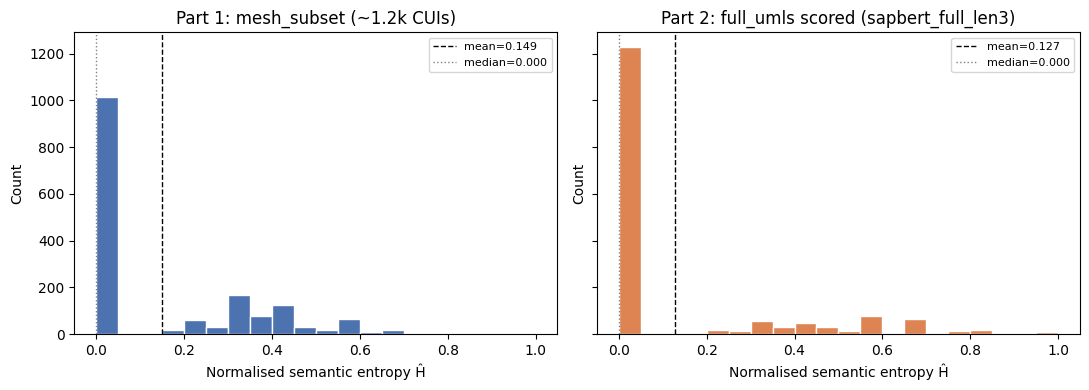

Saved figure -> /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/fig_entropy_mesh_vs_full_umls.png

=== Bimodality check ===
mesh_subset: %≈0=61.5 | % (0.05,0.20]=1.0 | %>0.20=37.5
  Bimodality heuristic PERSISTS (zero-spike≥40% AND unstable-tail≥15% AND middle < tail).
full_umls (scored): %≈0=75.1 | % (0.05,0.20]=0.1 | %>0.20=24.8
  Bimodality heuristic PERSISTS (zero-spike≥40% AND unstable-tail≥15% AND middle < tail).

Conclusion: under the ~2,600× deeper candidate pool, Part 1-style bimodality still appears.


In [8]:
# === PART 2: mesh vs full_umls comparison ===================================
import matplotlib.pyplot as plt

assert "df_entropy_compare" in globals(), "Run the CUI assignment / entropy cell first."

# Align UNASSIGNED / all_unassigned columns if present from patched P2.4
if "all_unassigned" not in df_entropy_compare.columns:
    # Infer: NaN full entropy ⇒ all-unassigned under patched scheme
    df_entropy_compare["all_unassigned"] = (
        df_entropy_compare["normalised_semantic_entropy_full"].isna()
    )

_scored = df_entropy_compare[~df_entropy_compare["all_unassigned"]].copy()
print(
    f"Comparison rows: {len(df_entropy_compare):,} | "
    f"scored (excl. all-UNASSIGNED): {len(_scored):,} | "
    f"all-UNASSIGNED: {df_entropy_compare['all_unassigned'].sum():,}"
)

_summary_rows = []
for label, col, df_ in [
    ("mesh_subset", "normalised_semantic_entropy_mesh", df_entropy_compare),
    ("full_umls_scored", "normalised_semantic_entropy_full", _scored),
]:
    s = df_[col].astype(float).dropna()
    _summary_rows.append({
        "pool": label,
        "n": int(s.shape[0]),
        "mean": float(s.mean()) if len(s) else np.nan,
        "median": float(s.median()) if len(s) else np.nan,
        "sd": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
        "pct_exactly_zero": float((s <= 1e-12).mean() * 100) if len(s) else np.nan,
        "pct_gt_0_20": float((s > 0.20).mean() * 100) if len(s) else np.nan,
    })
_summary_rows.append({
    "pool": "full_umls_all_unassigned",
    "n": int(df_entropy_compare["all_unassigned"].sum()),
    "mean": np.nan, "median": np.nan, "sd": np.nan,
    "pct_exactly_zero": np.nan, "pct_gt_0_20": np.nan,
})

df_entropy_summary = pd.DataFrame(_summary_rows)
print("=== Normalised semantic entropy summary ===")
display(df_entropy_summary)

print("\n=== Per-model means (normalised H; full excl. all-UNASSIGNED) ===")
display(
    _scored.groupby("model_name")[
        ["normalised_semantic_entropy_mesh", "normalised_semantic_entropy_full"]
    ].mean().round(4)
)

# --- Per-model mesh↔full zero/nonzero transition matrices (NOT pooled) ---
def _zf(s):
    out = pd.Series(np.nan, index=s.index, dtype=float)
    v = s.notna()
    out.loc[v] = (s.loc[v].astype(float) <= 1e-12).astype(float)
    return out

_tm = df_entropy_compare.copy()
_tm = _tm[~_tm["all_unassigned"]]
_tm["mesh_zero"] = _zf(_tm["normalised_semantic_entropy_mesh"])
_tm["full_zero"] = _zf(_tm["normalised_semantic_entropy_full"])
_tm = _tm.dropna(subset=["mesh_zero", "full_zero"])

print("\n=== Per-model transition matrices: mesh zero/nonzero → full zero/nonzero ===")
_trans_rows = []
for model, g in _tm.groupby("model_name"):
    mat = pd.crosstab(
        g["mesh_zero"].map({1.0: "mesh_zero", 0.0: "mesh_nonzero"}),
        g["full_zero"].map({1.0: "full_zero", 0.0: "full_nonzero"}),
        dropna=False,
    )
    # ensure all 4 cells present
    for r in ["mesh_zero", "mesh_nonzero"]:
        if r not in mat.index:
            mat.loc[r] = 0
    for c in ["full_zero", "full_nonzero"]:
        if c not in mat.columns:
            mat[c] = 0
    mat = mat.reindex(index=["mesh_zero", "mesh_nonzero"],
                      columns=["full_zero", "full_nonzero"]).fillna(0).astype(int)
    print(f"\n{model} (n={len(g)}):")
    display(mat)
    _trans_rows.append({
        "model_name": model,
        "n": int(len(g)),
        "zero_to_zero": int(mat.loc["mesh_zero", "full_zero"]),
        "zero_to_nonzero": int(mat.loc["mesh_zero", "full_nonzero"]),
        "nonzero_to_zero": int(mat.loc["mesh_nonzero", "full_zero"]),
        "nonzero_to_nonzero": int(mat.loc["mesh_nonzero", "full_nonzero"]),
    })

df_mesh_full_transitions = pd.DataFrame(_trans_rows)
print("\n(Pooled reference — do not use for claims; per-model above is primary)")
_pooled = pd.crosstab(
    _tm["mesh_zero"].map({1.0: "mesh_zero", 0.0: "mesh_nonzero"}),
    _tm["full_zero"].map({1.0: "full_zero", 0.0: "full_nonzero"}),
)
display(_pooled)

_tab_dir = Path("..") / "outputs" / "rq1" / "tables"
if not _tab_dir.exists():
    _tab_dir = Path("outputs") / "rq1" / "tables"
_tab_dir.mkdir(parents=True, exist_ok=True)
df_mesh_full_transitions.to_csv(
    _tab_dir / "rq1_mesh_full_zero_nonzero_transitions_per_model.csv", index=False
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, title, color, df_ in [
    (axes[0], "normalised_semantic_entropy_mesh",
     "Part 1: mesh_subset (~1.2k CUIs)", "#4C72B0", df_entropy_compare),
    (axes[1], "normalised_semantic_entropy_full",
     f"Part 2: full_umls scored ({_pool_config_name})", "#DD8452", _scored),
]:
    vals = df_[col].astype(float).dropna().values
    ax.hist(vals, bins=20, color=color, edgecolor="white", range=(0, 1))
    if len(vals):
        ax.axvline(np.mean(vals), color="black", ls="--", lw=1, label=f"mean={np.mean(vals):.3f}")
        ax.axvline(np.median(vals), color="gray", ls=":", lw=1, label=f"median={np.median(vals):.3f}")
    ax.set_title(title)
    ax.set_xlabel("Normalised semantic entropy Ĥ")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
plt.tight_layout()
_fig_path = _out_dir / "fig_entropy_mesh_vs_full_umls.png"
plt.savefig(_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure -> {_fig_path.resolve()}")

_mesh = df_entropy_compare["normalised_semantic_entropy_mesh"].astype(float)
_full = _scored["normalised_semantic_entropy_full"].astype(float)

def _bimodality_note(name, s):
    pct0 = (s <= 1e-12).mean() * 100
    pct_mid = ((s > 0.05) & (s <= 0.20)).mean() * 100
    pct_hi = (s > 0.20).mean() * 100
    persists = (pct0 >= 40) and (pct_hi >= 15) and (pct_mid < pct_hi)
    print(f"{name}: %≈0={pct0:.1f} | % (0.05,0.20]={pct_mid:.1f} | %>0.20={pct_hi:.1f}")
    print(f"  Bimodality heuristic {'PERSISTS' if persists else 'DOES NOT PERSIST'} "
          f"(zero-spike≥40% AND unstable-tail≥15% AND middle < tail).")
    return persists

print("\n=== Bimodality check ===")
_bimod_mesh = _bimodality_note("mesh_subset", _mesh)
_bimod_full = _bimodality_note("full_umls (scored)", _full)
print(
    "\nConclusion: under the ~2,600× deeper candidate pool, Part 1-style bimodality "
    + ("still appears." if _bimod_full else "does not clearly persist.")
)


## P2.6) Placeholder — `PREFERRED_ONLY` sensitivity rerun

Set `PREFERRED_ONLY = True` in the pool-preparation cell and re-run **P2.1 → P2.5**.
That rebuilds a separate embedding/FAISS cache (`sapbert_pref_tty_len{MIN_FORM_LEN}`)
and should append / display preferred-only summary numbers beside the primary
full-vocabulary results below.

Primary configuration remains **full vocabulary + length filter** (synonym recall
matters; preferred-only is sensitivity only).


In [9]:
# === PART 2: PREFERRED_ONLY sensitivity placeholder =========================
# After rerunning P2.1–P2.5 with PREFERRED_ONLY=True, store the summary row here.
# This cell does not recompute embeddings; it only records / displays a slot.

if "df_entropy_summary" in globals():
    print("Current (active config) summary:")
    display(df_entropy_summary)
else:
    print("No df_entropy_summary yet — run P2.5 first.")

# Manual append slot (filled after preferred-only rerun):
_preferred_only_summary_row = {
    "pool": "preferred_only_PT_PN",
    "n": None,
    "mean": None,
    "median": None,
    "sd": None,
    "pct_exactly_zero": None,
    "pct_gt_0_20": None,
    "note": "Re-run P2.1–P2.5 with PREFERRED_ONLY=True, then paste values here.",
}
print("\nPreferred-only placeholder row (fill after sensitivity rerun):")
display(pd.DataFrame([_preferred_only_summary_row]))

# Optional: if a preferred-only comparison CSV was saved under a distinct name, load it.
_pref_csv = _out_dir / "entropy_full_umls_preferred_only.csv"
if _pref_csv.exists():
    _df_pref = pd.read_csv(_pref_csv)
    _s = _df_pref["normalised_semantic_entropy_full"].astype(float)
    _row = {
        "pool": "preferred_only_PT_PN",
        "n": int(_s.shape[0]),
        "mean": float(_s.mean()),
        "median": float(_s.median()),
        "sd": float(_s.std(ddof=1)),
        "pct_exactly_zero": float((_s <= 1e-12).mean() * 100),
        "pct_gt_0_20": float((_s > 0.20).mean() * 100),
    }
    display(pd.concat([df_entropy_summary, pd.DataFrame([_row])], ignore_index=True))
else:
    print(f"(No {_pref_csv.name} yet — after preferred-only rerun, save compare CSV there.)")


Current (active config) summary:


,pool,n,mean,median,sd,pct_exactly_zero,pct_gt_0_20
0,mesh_subset,1650,0.148864,0.0,0.204820,61.515152,37.454545
1,full_umls_scored,1637,0.127175,0.0,0.238488,75.137447,24.801466
2,full_umls_all_unassigned,13,NaN,NaN,NaN,NaN,NaN



Preferred-only placeholder row (fill after sensitivity rerun):


,pool,n,mean,median,sd,pct_exactly_zero,pct_gt_0_20,note
0,preferred_only_PT_PN,None,None,None,None,None,None,"Re-run P2.1–P2.5 with PREFERRED_ONLY=True, the..."


(No entropy_full_umls_preferred_only.csv yet — after preferred-only rerun, save compare CSV there.)


## P2.7) Extended top-k sweep (batch / nbconvert-safe) + k-selection

**Kernel prerequisites (from P2.1–P2.4, not Setup alone):**
`_faiss_index`, `_embed_with_model`, `_unique_forms`, `df_model_part1`,
`CAND_GEN_COLUMN`, `assign_with_encoder_scores`, `_entropy_from_labels`,
`_model_hf`, `QUERY_TEXT_COLUMN`, `EXACT_MATCH_COLUMN`, `UNASSIGNED`, `_norm_cui`,
`_device`, `SAPBERT_ID`.

**Batch design:** one FAISS pass at \(k_{\max}=1000\) (checkpointed); depths are
prefix slices. Re-rank order is fail-fast: **250 first** → integrity assert → then
250, 500, 1000, 100, 50, 10 (existing per-(model,k) CSVs are skipped on resume).


### P2.7a) Checkpointed FAISS retrieval at \(k_{\max}=1000\)

Writes/loads `outputs/rq1/intermediate/faiss_shortlist_{I,D}_k1000.npy` and
`faiss_shortlist_query_texts.json`. Skips search if all three files already exist.


In [ ]:
# === PART 2: Extended top-k sweep — Cell 1: FAISS k_max=1000 (checkpointed) ===
import sys
import time
from datetime import datetime, timezone
from transformers import AutoModel, AutoTokenizer

def _log(msg: str):
    print(f"[{datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}] {msg}")
    sys.stdout.flush()

K_GRID_EXT = [10, 50, 100, 250, 500, 1000]
K_MAX_EXT = 1000
# Fail-fast order: 250 first (assert), then remaining including 250 (resume-SKIP)
K_ORDER_EXT = [250, 500, 1000, 100, 50, 10]
assert K_MAX_EXT == max(K_GRID_EXT)

_needed = [
    "_faiss_index", "_embed_with_model", "_unique_forms", "df_model_part1",
    "CAND_GEN_COLUMN", "SAPBERT_ID", "_device",
]
_missing = [n for n in _needed if n not in globals()]
if _missing:
    raise RuntimeError(
        "P2.7 requires P2.1–P2.4 state in this kernel. Missing: " + ", ".join(_missing)
    )

_inter_dir = Path("..") / "outputs" / "rq1" / "intermediate"
if not _inter_dir.exists():
    _inter_dir = Path("outputs") / "rq1" / "intermediate"
_inter_dir.mkdir(parents=True, exist_ok=True)

_I_path = _inter_dir / "faiss_shortlist_I_k1000.npy"
_D_path = _inter_dir / "faiss_shortlist_D_k1000.npy"
_Q_path = _inter_dir / "faiss_shortlist_query_texts.json"

_unique_cand_texts = (
    df_model_part1[CAND_GEN_COLUMN].fillna("").astype(str).drop_duplicates().tolist()
)
_log(f"FAISS queries n={len(_unique_cand_texts):,} col={CAND_GEN_COLUMN!r}")
_log(f"Index type={type(_faiss_index).__name__} ntotal={_faiss_index.ntotal:,}")

_t0 = time.perf_counter()
if (
    _I_path.exists() and _I_path.stat().st_size > 0
    and _D_path.exists() and _D_path.stat().st_size > 0
    and _Q_path.exists() and _Q_path.stat().st_size > 0
):
    _log(f"SKIP FAISS search — checkpoint exists: {_I_path.name}, {_D_path.name}, {_Q_path.name}")
    _I_kmax = np.load(_I_path)
    _D_kmax = np.load(_D_path)
    with open(_Q_path, "r", encoding="utf-8") as _f:
        _unique_cand_texts = json.load(_f)
    if _I_kmax.shape[0] != len(_unique_cand_texts) or _I_kmax.shape[1] != K_MAX_EXT:
        raise RuntimeError(
            f"Checkpoint shape mismatch: I={_I_kmax.shape} vs "
            f"n_queries={len(_unique_cand_texts)} k_max={K_MAX_EXT}. Delete checkpoints and rerun."
        )
else:
    _log(f"Running SapBERT query embed + FAISS search k_max={K_MAX_EXT} ...")
    _sap_tok = AutoTokenizer.from_pretrained(SAPBERT_ID)
    _sap_mdl = AutoModel.from_pretrained(SAPBERT_ID)
    _sap_mdl.to(_device).eval()
    if _device == "cuda":
        _sap_mdl.half()

    _sap_q = _embed_with_model(
        _sap_mdl, _sap_tok, _unique_cand_texts,
        batch_size=64, max_len=64, desc=f"SapBERT q (k_max={K_MAX_EXT})"
    )
    _q_norms = np.linalg.norm(_sap_q, axis=1)
    _log(f"Query L2 norms min={_q_norms.min():.6f} max={_q_norms.max():.6f}")
    assert np.allclose(_q_norms, 1.0, atol=1e-3), "Queries must be L2-normalised for IndexFlatIP"

    _D_kmax, _I_kmax = _faiss_index.search(_sap_q.astype(np.float32), K_MAX_EXT)
    assert _I_kmax.shape == (len(_unique_cand_texts), K_MAX_EXT)

    # Checkpoint BEFORE any re-ranking
    np.save(_I_path, _I_kmax.astype(np.int64))
    np.save(_D_path, _D_kmax.astype(np.float32))
    with open(_Q_path, "w", encoding="utf-8") as _f:
        json.dump(_unique_cand_texts, _f)
    _log(f"CHECKPOINTED shortlist -> {_I_path.resolve()}")
    _log(f"CHECKPOINTED shortlist -> {_D_path.resolve()}")
    _log(f"CHECKPOINTED queries   -> {_Q_path.resolve()}")

    del _sap_mdl, _sap_tok, _sap_q
    gc.collect()
    if _device == "cuda":
        torch.cuda.empty_cache()

_log(f"FAISS shortlist ready shape={_I_kmax.shape} elapsed={time.perf_counter()-_t0:.1f}s")

# Build prefix-slice helper from checkpoint
_text_to_candforms_kmax = {}
for t, idxs, scs in zip(_unique_cand_texts, _I_kmax, _D_kmax):
    _text_to_candforms_kmax[t] = [
        (_unique_forms[int(ix)], float(sc), int(ix))
        for ix, sc in zip(idxs, scs) if int(ix) >= 0
    ]

def shortlist_prefix(cand_key: str, k: int):
    """Prefix slice of the single k_max=1000 shortlist (no new FAISS query)."""
    return _text_to_candforms_kmax.get(cand_key, [])[:k]

_t0s = _unique_cand_texts[0]
assert [ix for _, _, ix in shortlist_prefix(_t0s, 250)] == [
    ix for _, _, ix in shortlist_prefix(_t0s, 1000)[:250]
], "Prefix nesting failed on sample query"
_log("Prefix nesting OK on sample query (k=250 == k1000[:250])")


### P2.7b) Per-model re-rank (fail-fast k=250, then resumable sweep)

Order: **250 → assert → 250, 500, 1000, 100, 50, 10**. Skips existing non-empty
`rq1_topk_sweep_{Model}_k{k}.csv`. Embeds unique shortlist forms once per encoder.


In [ ]:
# === PART 2: Per-model re-rank (fail-fast + resumable) ======================
import sys
import time
from datetime import datetime, timezone
from transformers import AutoModel, AutoTokenizer

def _log(msg: str):
    print(f"[{datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}] {msg}")
    sys.stdout.flush()

_needed2 = [
    "shortlist_prefix", "_text_to_candforms_kmax", "_I_kmax", "K_ORDER_EXT", "K_GRID_EXT",
    "assign_with_encoder_scores", "_entropy_from_labels", "_embed_with_model",
    "_model_hf", "df_model_part1", "QUERY_TEXT_COLUMN", "CAND_GEN_COLUMN",
    "EXACT_MATCH_COLUMN", "UNASSIGNED", "_norm_cui", "_device",
]
_missing2 = [n for n in _needed2 if n not in globals()]
if _missing2:
    raise RuntimeError("Run P2.7a first — missing: " + ", ".join(_missing2))

_tab_dir = Path("..") / "outputs" / "rq1" / "tables"
if not _tab_dir.exists():
    _tab_dir = Path("outputs") / "rq1" / "tables"
_tab_dir.mkdir(parents=True, exist_ok=True)

# Prior reference from rq1_topk_sensitivity_summary.csv (all_instances, k=250)
PRIOR_MEAN_H_K250 = {
    "BERT-base": 0.128230,
    "BioBERT": 0.127196,
    "PubMedBERT": 0.130300,
}
PRIOR_SPREAD_K250 = 0.003104
FAILFAST_TOL = 0.002

MODELS_ORDER = ["BERT-base", "BioBERT", "PubMedBERT"]

def _sweep_csv_path(model_name: str, k: int) -> Path:
    safe = str(model_name).replace(" ", "").replace("/", "_")
    return _tab_dir / f"rq1_topk_sweep_{safe}_k{int(k)}.csv"

def _csv_ready(path: Path) -> bool:
    return path.exists() and path.stat().st_size > 0

# Unique forms in k=1000 shortlist union (embed once per model)
_need_forms_ext = sorted({
    form for forms in _text_to_candforms_kmax.values() for form, _, _ in forms
})
_log(f"Unique surface forms in k=1000 union: {len(_need_forms_ext):,} "
     f"(embed once per encoder, not per mention×candidate)")

_encoder_q_cache_ext = {}
_encoder_form_cache_ext = {}

def _ensure_encoder_cache(model_name: str):
    if model_name in _encoder_q_cache_ext and model_name in _encoder_form_cache_ext:
        return
    idxs = list(df_model_part1.groupby("model_name").groups[model_name])
    g = df_model_part1.loc[idxs]
    hf_id = _model_hf[model_name]
    _log(f"Caching encoder embeddings: {model_name} ({hf_id})")
    t_emb = time.perf_counter()
    tok = AutoTokenizer.from_pretrained(hf_id)
    mdl = AutoModel.from_pretrained(hf_id, weights_only=False)
    mdl.to(_device).eval()
    if _device == "cuda":
        mdl.half()

    texts = g[QUERY_TEXT_COLUMN].fillna("").astype(str).tolist()
    q_vecs = _embed_with_model(
        mdl, tok, texts, batch_size=32, max_len=128, desc=f"{model_name} queries"
    )
    form_vecs = _embed_with_model(
        mdl, tok, _need_forms_ext, batch_size=64, max_len=64,
        desc=f"{model_name} unique forms"
    )
    _encoder_q_cache_ext[model_name] = (idxs, q_vecs)
    _encoder_form_cache_ext[model_name] = {
        f: form_vecs[i] for i, f in enumerate(_need_forms_ext)
    }
    del mdl, tok, q_vecs, form_vecs
    gc.collect()
    if _device == "cuda":
        torch.cuda.empty_cache()
    _log(f"Encoder cache ready for {model_name} elapsed={time.perf_counter()-t_emb:.1f}s")


def _rerank_one_model_k(model_name: str, k: int) -> pd.DataFrame:
    """Re-rank one model at depth k; return per-(instance,model) entropy rows."""
    global _rej
    _rej = Counter()
    _ensure_encoder_cache(model_name)
    idxs, q_vecs = _encoder_q_cache_ext[model_name]
    form_to_vec = _encoder_form_cache_ext[model_name]

    pred_by_row = {}
    for local_i, row_i in enumerate(idxs):
        row = df_model_part1.loc[row_i]
        qtext = str(row[QUERY_TEXT_COLUMN]) if pd.notna(row[QUERY_TEXT_COLUMN]) else ""
        mtext = (
            str(row[EXACT_MATCH_COLUMN])
            if EXACT_MATCH_COLUMN in row.index and pd.notna(row[EXACT_MATCH_COLUMN])
            else ""
        )
        cand_key = str(row[CAND_GEN_COLUMN]) if pd.notna(row[CAND_GEN_COLUMN]) else ""
        qv = q_vecs[local_i]
        form_scores = {}
        for form, sap_sc, ix in shortlist_prefix(cand_key, k):
            fv = form_to_vec.get(form)
            if fv is not None:
                form_scores[form] = float(np.dot(qv, fv))
        cui, sc, path = assign_with_encoder_scores(qtext, mtext, form_scores)
        pred_by_row[row_i] = _norm_cui(cui) if cui != UNASSIGNED else UNASSIGNED

    g = df_model_part1.loc[idxs, ["instance_id", "model_name", QUERY_TEXT_COLUMN]].copy()
    g["predicted_cui_full"] = [pred_by_row[i] for i in idxs]

    rows = []
    for (inst, model), grp in g.groupby(["instance_id", "model_name"]):
        ent = _entropy_from_labels(grp["predicted_cui_full"].tolist())
        n_uniq_txt = int(grp[QUERY_TEXT_COLUMN].fillna("").astype(str).nunique())
        rows.append({
            "k": int(k),
            "instance_id": inst,
            "model_name": model,
            "n_unique_input_text": n_uniq_txt,
            "structural_zero": bool(n_uniq_txt <= 1),
            **ent,
        })
    return pd.DataFrame(rows)


def _load_or_run_model_k(model_name: str, k: int) -> pd.DataFrame:
    path = _sweep_csv_path(model_name, k)
    if _csv_ready(path):
        _log(f"SKIP existing {path.name}")
        return pd.read_csv(path)
    t0 = time.perf_counter()
    _log(f"START re-rank model={model_name} k={k}")
    df_m = _rerank_one_model_k(model_name, k)
    df_m.to_csv(path, index=False)
    _log(
        f"DONE  re-rank model={model_name} k={k} "
        f"rows={len(df_m)} elapsed={time.perf_counter()-t0:.1f}s -> {path.name}"
    )
    return df_m


def _means_and_spread_from_model_dfs(dfs_by_model: dict) -> tuple:
    """Return (means_dict, spread) using scored rows only (excl. all_unassigned)."""
    means = {}
    for m, df_m in dfs_by_model.items():
        scored = df_m.loc[~df_m["all_unassigned"].astype(bool), "normalised_semantic_entropy_full"]
        means[m] = float(scored.astype(float).mean()) if len(scored) else float("nan")
    vals = [v for v in means.values() if np.isfinite(v)]
    spread = float(max(vals) - min(vals)) if vals else float("nan")
    return means, spread


def _failfast_assert_k250(dfs_by_model: dict):
    means, spread = _means_and_spread_from_model_dfs(dfs_by_model)
    _log(f"FAIL-FAST k=250 means={ {m: round(means[m], 6) for m in MODELS_ORDER} }")
    _log(f"FAIL-FAST k=250 spread={spread:.6f} (prior={PRIOR_SPREAD_K250})")
    for m in MODELS_ORDER:
        prior = PRIOR_MEAN_H_K250[m]
        got = means[m]
        delta = abs(got - prior)
        _log(f"  {m}: mean={got:.6f} prior={prior:.6f} |Δ|={delta:.6f}")
        if delta > FAILFAST_TOL:
            raise AssertionError(
                f"FAIL-FAST: {m} k=250 mean {got:.6f} differs from prior {prior} "
                f"by {delta:.6f} > tol {FAILFAST_TOL}. Aborting before deeper k."
            )
    if abs(spread - PRIOR_SPREAD_K250) > FAILFAST_TOL:
        raise AssertionError(
            f"FAIL-FAST: k=250 spread {spread:.6f} differs from prior "
            f"{PRIOR_SPREAD_K250} by more than {FAILFAST_TOL}. Aborting."
        )
    _log("FAIL-FAST ASSERT OK — continuing remaining depths")


# ---- Sweep ----
_log(f"K_ORDER_EXT={K_ORDER_EXT}")
_failfast_done = False

for k in K_ORDER_EXT:
    _log(f"===== depth k={k} =====")
    dfs_k = {}
    for model_name in MODELS_ORDER:
        dfs_k[model_name] = _load_or_run_model_k(model_name, k)

    if k == 250 and not _failfast_done:
        _failfast_assert_k250(dfs_k)
        _failfast_done = True

_log("All (model, k) re-rank steps complete (or skipped).")


### P2.7c) Integrity assertions (post-sweep)

(b) Distinct per-model means at every \(k\).  
(c) Prefix nesting on `_I_kmax`.  
(d) Per-model **`all_unassigned`** counts (instances where all variants are unassigned).


In [ ]:
# === PART 2: Integrity assertions (extended top-k sweep) ====================
import sys
from datetime import datetime, timezone

def _log(msg: str):
    print(f"[{datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}] {msg}")
    sys.stdout.flush()

_needed3 = ["_I_kmax", "K_GRID_EXT", "K_ORDER_EXT", "shortlist_prefix", "_unique_cand_texts", "_tab_dir", "MODELS_ORDER"]
_missing3 = [n for n in _needed3 if n not in globals()]
if _missing3:
    raise RuntimeError("Run P2.7a–b first — missing: " + ", ".join(_missing3))

def _sweep_csv_path(model_name: str, k: int) -> Path:
    safe = str(model_name).replace(" ", "").replace("/", "_")
    return _tab_dir / f"rq1_topk_sweep_{safe}_k{int(k)}.csv"

# Load all per-(model,k) CSVs from disk
_parts = []
for k in K_GRID_EXT:
    for m in MODELS_ORDER:
        p = _sweep_csv_path(m, k)
        if not (p.exists() and p.stat().st_size > 0):
            raise FileNotFoundError(f"Missing sweep CSV for assert: {p}")
        _parts.append(pd.read_csv(p))
df_topk_sweep_entropy = pd.concat(_parts, ignore_index=True)
_log(f"Loaded sweep entropy from disk: rows={len(df_topk_sweep_entropy):,}")

# Require all_unassigned column (not n_unassigned / dominant_cluster_full)
if "all_unassigned" not in df_topk_sweep_entropy.columns:
    raise AssertionError(
        "INTEGRITY FAIL (d): CSV missing all_unassigned column. "
        "Do not substitute n_unassigned or dominant_cluster_full."
    )

# (b) Distinct per-model means at every k
_log("(b) Per-model mean H distinctness:")
for k in K_GRID_EXT:
    means = {}
    for m in MODELS_ORDER:
        g = df_topk_sweep_entropy[
            (df_topk_sweep_entropy["k"] == k)
            & (df_topk_sweep_entropy["model_name"] == m)
            & (~df_topk_sweep_entropy["all_unassigned"].astype(bool))
        ]["normalised_semantic_entropy_full"].astype(float)
        means[m] = float(g.mean()) if len(g) else float("nan")
    _log(f"  k={k}: " + ", ".join(f"{m}={means[m]:.6f}" for m in MODELS_ORDER))
    vals = [means[m] for m in MODELS_ORDER if np.isfinite(means[m])]
    if len(vals) > 1 and (max(vals) - min(vals)) < 1e-12:
        raise AssertionError(
            f"INTEGRITY FAIL (b): identical per-model mean H at k={k} "
            f"({vals[0]:.6f}) — known bug signature, not a finding."
        )
_log("  ASSERT OK (b)")

# (c) Prefix nesting
_log("(c) Prefix nesting on _I_kmax:")
assert _I_kmax.shape[1] >= 250
_head = _I_kmax[:, :250]
if not np.array_equal(_I_kmax[:, :250], _head):
    raise AssertionError("INTEGRITY FAIL (c): internal slice inconsistency")
_mismatch = 0
for qi, t in enumerate(_unique_cand_texts[: min(50, len(_unique_cand_texts))]):
    pref = [ix for _, _, ix in shortlist_prefix(t, 250)]
    mat = [int(x) for x in _I_kmax[qi, :250].tolist() if int(x) >= 0]
    if pref != mat:
        _mismatch += 1
if _mismatch:
    raise AssertionError(
        f"INTEGRITY FAIL (c): shortlist_prefix vs _I_kmax[:, :250] mismatch "
        f"on {_mismatch} sample queries"
    )
_log(f"  ASSERT OK (c): _I_kmax.shape={_I_kmax.shape}")

# (d) all_unassigned counts — NOT n_unassigned, NOT dominant_cluster_full
_log("(d) Per-model all_unassigned instance counts across k:")
_un_rows = []
for k in K_GRID_EXT:
    for m in MODELS_ORDER:
        g = df_topk_sweep_entropy[
            (df_topk_sweep_entropy["k"] == k) & (df_topk_sweep_entropy["model_name"] == m)
        ]
        # count of instances where all variants are unassigned
        n_all_un = int(g["all_unassigned"].astype(bool).sum())
        _un_rows.append({"k": k, "model_name": m, "n_all_unassigned": n_all_un})
        _log(f"  k={k} {m}: all_unassigned={n_all_un}")
df_unassigned_by_k = pd.DataFrame(_un_rows)
_un_tab = df_unassigned_by_k.pivot_table(
    index="k", columns="model_name", values="n_all_unassigned"
)
_log("all_unassigned pivot:")
print(_un_tab.to_string())
sys.stdout.flush()

for k in K_GRID_EXT:
    row = _un_tab.loc[k]
    bert = float(row.get("BERT-base", np.nan))
    bio = float(row.get("BioBERT", np.nan))
    pub = float(row.get("PubMedBERT", np.nan))
    if not (bert > bio and bert > pub):
        _log(
            f"  WARNING k={k}: BERT-base all_unassigned ({bert}) is NOT materially "
            f"higher than BioBERT ({bio}) / PubMedBERT ({pub})"
        )
    else:
        _log(f"  k={k}: BERT-base all_unassigned higher than BioBERT/PubMedBERT OK")

_log("Integrity assertions (b–c) passed; (d) reported via all_unassigned.")


### P2.7d) k-selection from disk → `outputs/rq1/k_selection.json`

Rebuilds `rq1_topk_sweep_full.csv` by reading per-(model,k) CSVs from disk (resume-safe).
SE reported at **every** \(k\); k=250 is the fixed SE reference (±20% warning at selected k).


In [ ]:
# === PART 2: k-selection rule (rebuild summary from disk) ===================
import sys
from datetime import datetime, timezone

def _log(msg: str):
    print(f"[{datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}] {msg}")
    sys.stdout.flush()

_needed4 = ["K_GRID_EXT", "MODELS_ORDER", "_tab_dir"]
_missing4 = [n for n in _needed4 if n not in globals()]
if _missing4:
    raise RuntimeError("Run P2.7a–c first — missing: " + ", ".join(_missing4))

THRESHOLD = 0.005
SE_WARN_LO, SE_WARN_HI = 0.008, 0.012
SE_REF_K = 250
SE_SELECTED_REL_TOL = 0.20  # warn if |SE_sel - SE_250| / SE_250 > 20%

def _sweep_csv_path(model_name: str, k: int) -> Path:
    safe = str(model_name).replace(" ", "").replace("/", "_")
    return _tab_dir / f"rq1_topk_sweep_{safe}_k{int(k)}.csv"

# ---- Rebuild combined tables strictly from disk ----
_parts = []
_summary_rows = []
for k in K_GRID_EXT:
    dfs_k = {}
    for m in MODELS_ORDER:
        p = _sweep_csv_path(m, k)
        if not (p.exists() and p.stat().st_size > 0):
            raise FileNotFoundError(f"Cannot build summary; missing {p}")
        df_m = pd.read_csv(p)
        if "all_unassigned" not in df_m.columns:
            raise KeyError(f"{p} missing all_unassigned")
        dfs_k[m] = df_m
        _parts.append(df_m)

    means, sds, zeros, n_scored, n_all_un = {}, {}, {}, {}, {}
    for m, df_m in dfs_k.items():
        scored = df_m.loc[~df_m["all_unassigned"].astype(bool), "normalised_semantic_entropy_full"].astype(float)
        means[m] = float(scored.mean()) if len(scored) else float("nan")
        sds[m] = float(scored.std(ddof=1)) if len(scored) > 1 else float("nan")
        zeros[m] = float((scored <= 1e-12).mean() * 100) if len(scored) else float("nan")
        n_scored[m] = int(len(scored))
        n_all_un[m] = int(df_m["all_unassigned"].astype(bool).sum())

    vals = [v for v in means.values() if np.isfinite(v)]
    spread = float(max(vals) - min(vals)) if vals else float("nan")

    for m in MODELS_ORDER:
        _summary_rows.append({
            "subset": "all_instances",
            "k": int(k),
            "model_name": m,
            "n_scored": n_scored[m],
            "n_all_unassigned": n_all_un[m],
            "mean_H": means[m],
            "sd_H": sds[m],
            "pct_exactly_zero": zeros[m],
            "between_model_spread_maxmin": spread,
        })
    _summary_rows.append({
        "subset": "all_instances",
        "k": int(k),
        "model_name": "__SPREAD__",
        "n_scored": int(sum(n_scored.values())),
        "n_all_unassigned": int(sum(n_all_un.values())),
        "mean_H": np.nan,
        "sd_H": np.nan,
        "pct_exactly_zero": np.nan,
        "between_model_spread_maxmin": spread,
    })
    _log(
        f"k={k} spread={spread:.6f} means="
        + ", ".join(f"{m}={means[m]:.4f}" for m in MODELS_ORDER)
        + f" all_unassigned=" + str({m: n_all_un[m] for m in MODELS_ORDER})
    )

df_topk_sweep_entropy = pd.concat(_parts, ignore_index=True)
df_topk_sweep_summary = pd.DataFrame(_summary_rows)

_full_path = _tab_dir / "rq1_topk_sweep_full.csv"
df_topk_sweep_summary.to_csv(_full_path, index=False)
df_topk_sweep_entropy.to_csv(_tab_dir / "rq1_topk_sweep_entropy_full.csv", index=False)
_log(f"Wrote {_full_path.resolve()} from disk CSVs ({len(df_topk_sweep_summary)} summary rows)")

# Spread map
_spread_map = {
    str(int(k)): float(
        df_topk_sweep_summary[
            (df_topk_sweep_summary["k"] == k)
            & (df_topk_sweep_summary["model_name"] == "__SPREAD__")
        ]["between_model_spread_maxmin"].iloc[0]
    )
    for k in K_GRID_EXT
}
_log("Spread by k: " + str({k: round(v, 6) for k, v in _spread_map.items()}))

# SE at EVERY k: mean over models of (instance-level SD / sqrt(n_scored))
_se_by_k = {}
_se_detail = []
for k in K_GRID_EXT:
    se_parts = []
    for m in MODELS_ORDER:
        g = df_topk_sweep_entropy[
            (df_topk_sweep_entropy["k"] == k)
            & (df_topk_sweep_entropy["model_name"] == m)
            & (~df_topk_sweep_entropy["all_unassigned"].astype(bool))
        ]["normalised_semantic_entropy_full"].astype(float)
        n = int(g.notna().sum())
        if n < 2:
            continue
        sd = float(g.std(ddof=1))
        se = sd / np.sqrt(n)
        se_parts.append(se)
        _se_detail.append({"k": int(k), "model_name": m, "n": n, "sd": sd, "se": se})
    _se_by_k[str(int(k))] = float(np.mean(se_parts)) if se_parts else float("nan")
    _log(f"SE@k={k}: mean_across_models={_se_by_k[str(int(k))]:.6f}")

_se_ref = _se_by_k[str(SE_REF_K)]
_log(f"SE reference (k={SE_REF_K}) = {_se_ref:.6f}")
if not (SE_WARN_LO <= _se_ref <= SE_WARN_HI):
    _log(
        f"WARNING: SE@{SE_REF_K}={_se_ref:.6f} outside [{SE_WARN_LO}, {SE_WARN_HI}]. "
        f"Threshold 0.005 (~½ of SE≈0.010) may need re-deriving."
    )

# k-selection rule
_k_selected = None
_rule_satisfied = False
for k in K_GRID_EXT:
    if _spread_map[str(int(k))] > THRESHOLD:
        continue
    later_ok = all(_spread_map[str(int(kk))] <= THRESHOLD for kk in K_GRID_EXT if kk >= k)
    if later_ok:
        _k_selected = int(k)
        _rule_satisfied = True
        break
if _k_selected is None:
    _k_selected = int(max(K_GRID_EXT))
    _rule_satisfied = False

_se_sel = _se_by_k[str(_k_selected)]
if np.isfinite(_se_ref) and _se_ref > 0 and np.isfinite(_se_sel):
    _se_rel = abs(_se_sel - _se_ref) / _se_ref
    if _se_rel > SE_SELECTED_REL_TOL:
        _log(
            f"WARNING: SE at selected k={_k_selected} ({_se_sel:.6f}) differs from "
            f"SE@{SE_REF_K} ({_se_ref:.6f}) by {_se_rel:.1%} (> {SE_SELECTED_REL_TOL:.0%})."
        )
    else:
        _log(
            f"SE at selected k={_k_selected} ({_se_sel:.6f}) within {SE_SELECTED_REL_TOL:.0%} "
            f"of SE@{SE_REF_K} ({_se_ref:.6f})."
        )

_k_selection = {
    "k_selected": _k_selected,
    "rule_satisfied": _rule_satisfied,
    "threshold": THRESHOLD,
    "se": _se_ref,
    "se_reference_k": SE_REF_K,
    "se_by_k": _se_by_k,
    "se_at_selected_k": _se_sel,
    "se_per_model_by_k": _se_detail,
    "spread_by_k": _spread_map,
    "k_grid": K_GRID_EXT,
    "k_order_batch": K_ORDER_EXT if "K_ORDER_EXT" in globals() else K_GRID_EXT,
    "prior_k250_spread_target": 0.003104,
    "prior_k250_means": {
        "BERT-base": 0.128230,
        "BioBERT": 0.127196,
        "PubMedBERT": 0.130300,
    },
    "notes": (
        "k is the smallest depth with spread<=threshold that remains so at all "
        "larger tested depths; else k=max(grid) with rule_satisfied=false. "
        "Summary rebuilt from per-(model,k) CSVs on disk."
    ),
}

_out_rq1 = Path("..") / "outputs" / "rq1"
if not _out_rq1.exists():
    _out_rq1 = Path("outputs") / "rq1"
_out_rq1.mkdir(parents=True, exist_ok=True)
_ksel_path = _out_rq1 / "k_selection.json"
with open(_ksel_path, "w", encoding="utf-8") as _f:
    json.dump(_k_selection, _f, indent=2)
_log(f"Wrote {_ksel_path.resolve()}")
_log(
    f"k_selected={_k_selected} rule_satisfied={_rule_satisfied} "
    f"threshold={THRESHOLD} se_ref={_se_ref:.6f}"
)

_cfg_path = Path("..") / "config.json"
if not _cfg_path.exists():
    _cfg_path = Path("config.json")
with open(_cfg_path, "r", encoding="utf-8") as _f:
    _cfg = json.load(_f)
_cfg["k_selection"] = "outputs/rq1/k_selection.json"
_cfg["topk_sweep_full"] = "outputs/rq1/tables/rq1_topk_sweep_full.csv"
with open(_cfg_path, "w", encoding="utf-8") as _f:
    json.dump(_cfg, _f, indent=2)
    _f.write("\n")
_log(f"Updated {_cfg_path.resolve()}")

print(pd.DataFrame([
    {"k": int(k), "spread": _spread_map[str(int(k))], "se": _se_by_k[str(int(k))],
     "selected": int(k) == _k_selected}
    for k in K_GRID_EXT
]).to_string(index=False))
sys.stdout.flush()
